In [1]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import datetime
import sys

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import subprocess

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import scipy.stats as stats

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    num_muts_column_name,
    DATASET_PATHS
)

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
run_jobs = False

In [3]:

if run_jobs:
    for mdn in ["esm_3b", "progen2-medium", "prot_bert", "esm_150m", "progen2-small", "esm_8m", "esm_35m", "esm_650m"]:

        cmd = f"python train_classifiers_over_embeddings.py --model_name {mdn}"
        print(cmd)

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        tmp_dir_name = f"collect_all_job_results_{timestamp}"
        tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

        os.makedirs(tmp_dir_path, exist_ok=True)

        run_lsf_job(cmd, 
                    local_script_dir=tmp_dir_path,
                    code_execution_dir=os.getcwd(),
                    conda_env_name="esm_env",
                    worker_idx=None,
                    gpu=True,
                    N_cores=6,
                    rusage="64GB")

    cmd = f"python train_classifiers_over_ohe.py"

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    tmp_dir_name = f"collect_all_job_results_{timestamp}"
    tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

    os.makedirs(tmp_dir_path, exist_ok=True)

    run_lsf_job(cmd, 
                local_script_dir=tmp_dir_path,
                code_execution_dir=os.getcwd(),
                conda_env_name="esm_env",
                worker_idx=None,
                gpu=False,
                N_cores=6,
                rusage="64GB")


    for mdn in ["esm_3b", "esm_150m", "progen2-small", "esm_8m", "esm_35m", "esm_650m"]:

        cmd = f"python train_classifiers_over_embeddings.py --model_name {mdn} --dataset_name lov --regression --external_labels_column activity --mean_embeddings"
        print(cmd)

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        tmp_dir_name = f"collect_all_job_results_{timestamp}"
        tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

        os.makedirs(tmp_dir_path, exist_ok=True)

        run_lsf_job(cmd, 
                    local_script_dir=tmp_dir_path,
                    code_execution_dir=os.getcwd(),
                    conda_env_name="esm_env",
                    worker_idx=None,
                    gpu=True,
                    N_cores=6,
                    rusage="64GB")


    cmd = f"python train_classifiers_over_ohe.py --dataset_name lov --regression --external_labels_column activity"

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    tmp_dir_name = f"collect_all_job_results_{timestamp}"
    tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

    os.makedirs(tmp_dir_path, exist_ok=True)

    run_lsf_job(cmd, 
                local_script_dir=tmp_dir_path,
                code_execution_dir=os.getcwd(),
                conda_env_name="esm_env",
                worker_idx=None,
                gpu=False,
                N_cores=6,
                rusage="64GB")



In [4]:
df = pd.read_csv(DATASET_PATHS["gfp"])
discrete_labels = get_labels("gfp", discrete=True)
continuous_labels = get_labels("gfp", discrete=True)


probabilities_by_mutations = []
numt_muts_column = num_muts_column_name["gfp"]

n_muts = np.unique(df[numt_muts_column].to_numpy())
n_muts = n_muts[n_muts > 0]
for i in n_muts:
    counts = np.unique(discrete_labels[df[numt_muts_column] == i], return_counts=True)
    row = np.array([
        np.array([i]).astype(float)[0].item(),
        counts[1][0] / sum(counts[1]), 
        1 - counts[1][0] / sum(counts[1])
    ])
    probabilities_by_mutations.append(row)

gfp_muts = np.stack(probabilities_by_mutations)[:,1:]

In [5]:
def plot_mutation_model_performance(
    color_map, 
    df_all, 
    pred_begin, 
    min_muts, 
    n_muts_to_check, 
    feature_to_plot, 
    probabilities_by_mutations=None,
    output_dir=None,
    min_max_y=False
):
    filtered_df_all = df_all[df_all["model_name"].isin(color_map.keys())]
    col_size = 1.35
    row_size = col_size * n_muts_to_check
    title_fontsize = 8
    label_fontsize = 9
    tick_fontsize = 9
    legend_fontsize = 7

    plot_boxplots = False
    fig, axs = plt.subplots(2, n_muts_to_check, figsize=(row_size, 0.3 + col_size*2), constrained_layout=True)

    if min_max_y:
        # calculate global y min/max for line plots if needed
        all_measurements = []
        for i in range(min_muts, min_muts+n_muts_to_check):
            sub_df = filtered_df_all[filtered_df_all["test_mutations"] == i]
            train_sub_df = sub_df[(sub_df["train_mutations"] < i) & (sub_df["train_mutations"] >= pred_begin)]
            for model in color_map.keys():
                vals = train_sub_df[(train_sub_df["model_name"] == model)][feature_to_plot].values
                vals = vals[~np.isnan(vals)]
                if len(vals) > 0:
                    all_measurements.extend(vals)
        if len(all_measurements) > 0:
            global_ymin = np.nanmin(all_measurements)
            global_ymax = np.nanmax(all_measurements)
        else:
            global_ymin = 0
            global_ymax = 1

    for i in range(min_muts, min_muts+n_muts_to_check):
        col = i - min_muts
        axs[0, col].grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        axs[1, col].grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        axs[0, col].spines['right'].set_visible(False)
        axs[1, col].spines['right'].set_visible(False)
        axs[0, col].spines['top'].set_visible(False)
        axs[1, col].spines['top'].set_visible(False)

        sub_df = filtered_df_all[filtered_df_all["test_mutations"] == i]
        train_sub_df = sub_df[(sub_df["train_mutations"] < i) & (sub_df["train_mutations"] >= pred_begin)]
        n_train_muts = len(np.unique(train_sub_df["train_mutations"]))
        x = np.arange(n_train_muts)
        width = 1/n_muts_to_check
        multiplier = 0

        # --- SWAP BEGINS: original axs[0] code moved to axs[1], and boxplot code to axs[0] ---

        # First plot what *was* on row 1 (boxplot) on axs[0]
        boxplot_data = []
        model_names = []
        
        for model in color_map.keys():
            box_vals = filtered_df_all[(filtered_df_all["test_mutations"] == i) & (filtered_df_all["model_name"] == model)][feature_to_plot].dropna().values
            if len(box_vals) > 0:
                if box_vals.ndim == 2:
                    box_vals = box_vals.squeeze()
                boxplot_data.append(box_vals)
                model_names.append(model)
                
        bp = axs[0, col].boxplot(
            boxplot_data,
            patch_artist=True,
            boxprops=dict(linewidth=1, color='black'),
            medianprops=dict(color='black', linewidth=1),
            whiskerprops=dict(linewidth=1, color='black'),
            capprops=dict(linewidth=1, color='black'),
            flierprops=dict(markerfacecolor='black', marker='o', markersize=3.5, markeredgecolor='black', linestyle='none')
        )        

        for patch, model in zip(bp['boxes'], model_names):
            patch.set_facecolor(color_map[model])
        axs[0, col].set_xlabel('Model', fontsize=label_fontsize, labelpad=3)
        axs[0, col].set_xticklabels([])
        axs[0, col].tick_params(axis='y', labelsize=tick_fontsize)

        if feature_to_plot == "top_100_pct":
            all_box_vals = np.concatenate([np.array(vals).flatten() for vals in boxplot_data if np.all(~np.isnan(vals))])
            y_min = np.nanmin(all_box_vals)
            y_max = np.nanmax(all_box_vals)
            y_pad = (y_max - y_min) * 0.1 if y_max > y_min else 0.05
            y_lower = max(0, y_min - y_pad)
            y_upper = min(1, y_max + y_pad)
            for s in [0.5, 0.2, 0.1]:
                dec_y_lower = np.ceil(y_lower / s) * s
                dec_y_upper = np.floor(y_upper / s) * s
                n_ticks = int((dec_y_upper - dec_y_lower) / s) + 1
                if n_ticks >= 3 and n_ticks <= 10:
                    tick_step = s
                    break
            else:
                tick_step = 0.1
                dec_y_lower = np.ceil(y_lower / tick_step) * tick_step
                dec_y_upper = np.floor(y_upper / tick_step) * tick_step

            y_ticks = np.arange(dec_y_lower, dec_y_upper + tick_step / 2, tick_step)
            y_ticks = np.clip(y_ticks, 0, 1)
            y_ticks = np.unique(np.round(y_ticks, 3))
            y_ticklabels = []
            for y in y_ticks:
                if np.isclose(y, 0.0):
                    y_ticklabels.append('0')
                elif np.isclose(y, 1.0):
                    y_ticklabels.append('1')
                elif tick_step >= 0.1:
                    y_ticklabels.append(str(int(y*10)/10))
                else:
                    y_ticklabels.append('{:.2f}'.format(y))
            axs[0, col].set_yticks(y_ticks)
            axs[0, col].set_yticklabels(y_ticklabels)
        else:
            print(vals)
            all_box_vals = np.concatenate([np.array(vals).flatten() for vals in boxplot_data if np.all(~np.isnan(vals))])
            y_min = np.nanmin(all_box_vals)
            y_max = np.nanmax(all_box_vals)
            y_pad = (y_max - y_min) * 0.1 if y_max > y_min else 0.05
            y_lower = y_min - y_pad
            y_upper = y_max + y_pad
            axs[0, col].set_ylim(y_lower, y_upper)

        if col == 0:
            axs[0, col].set_ylabel(ylabel_dict[feature_to_plot], labelpad=6, fontsize=label_fontsize)
        
        fix_ticks(axs[0, col], x=False, y=True, every_other=False, ylim=[y_lower, y_upper], fontsize=tick_fontsize)


        # Next, plot what *was* on row 0 (line/bar) on axs[1]
        if not plot_boxplots:
            for model in color_map.keys():
                order = np.argsort(train_sub_df[(train_sub_df["model_name"] == model)]["train_mutations"])
                measurement = train_sub_df[(train_sub_df["model_name"] == model)].iloc[order][feature_to_plot]
                measurement = measurement.round(2)
                print("#########################")
                print(x)
                print(measurement)
                print("#########################")
                axs[1, col].plot(
                    x, measurement, marker='o', 
                    color=color_map.get(model, None), 
                    label=model if x[0] == 0 else "", 
                    markersize=3, linewidth=1, alpha=0.7
                )
            if col == 0:
                axs[1, col].set_ylabel(ylabel_dict[feature_to_plot], labelpad=6, fontsize=label_fontsize)
            # There is no 'labelpad' argument for set_title in matplotlib.
            # You can control spacing with pad argument (from matplotlib 3.2 onward) or use '\n' in the text.
            axs[0, col].set_title('Mutations in test: %d\n' % i, fontsize=title_fontsize, pad=3)
            axs[1, col].set_xlabel('Mutations\nin train', fontsize=label_fontsize, labelpad=1)
            axs[1, col].set_xticks(x)
            axs[1, col].set_xticklabels(list(range(pred_begin, n_train_muts+pred_begin)), fontsize=tick_fontsize)
            axs[1, col].tick_params(axis='y', labelsize=tick_fontsize)
            axs[1, col].tick_params(axis='x', labelsize=tick_fontsize)
            if feature_to_plot == "roc":
                if pred_begin == 2:
                    axs[1, col].set_ylim(0.6, 0.95)
                else:
                    axs[1, col].set_ylim(0.3, 0.95)
            if min_max_y:
                axs[1, col].set_ylim(global_ymin, global_ymax)
            
            if probabilities_by_mutations is not None:
                print(probabilities_by_mutations)
                precision = probabilities_by_mutations[i-1][1]
                if feature_to_plot == "precision" or feature_to_plot == "top_100_pct":
                    axs[1, col].axhline(y=precision, color='black', linestyle='--', linewidth=0.8)
            if feature_to_plot == "top_100_pct":
                axs[1, col].set_ylim(0, 1.05)
                axs[1, col].set_yticks([0, 0.5, 1])
                axs[1, col].set_yticklabels(['0', '0.5', '1'])
            fix_ticks(axs[1, col], x=False, y=True, every_other=False, ylim=None, ybreaks=3, fontsize=tick_fontsize)
        else:
            for model in color_map.keys():
                order = np.argsort(train_sub_df[(train_sub_df["model_name"] == model)]["train_mutations"])
                measurement = train_sub_df[(train_sub_df["model_name"] == model)].iloc[order][feature_to_plot]
                measurement = measurement.round(2)
                offset = width * multiplier
                rects = axs[1, col].bar(x + offset, measurement, width, color=color_map.get(model, None), label=model if x[0] == 0 else "")
                multiplier += 1
            if col == 0:
                axs[1, col].set_ylabel(feature_to_plot, labelpad=6, fontsize=label_fontsize)
                if min_muts == 3:
                    axs[1, col].legend(loc='lower left', ncols=1, fontsize=legend_fontsize)        
            axs[1, col].set_xlabel('Mutations\nin train', fontsize=label_fontsize, labelpad=1)
            axs[1, col].set_xticks(x + width)
            axs[1, col].set_xticklabels(list(range(pred_begin, n_train_muts+pred_begin)), fontsize=tick_fontsize)
            axs[1, col].tick_params(axis='y', labelsize=tick_fontsize)
            axs[1, col].tick_params(axis='x', labelsize=tick_fontsize)
            axs[1, col].set_ylim(0.3, 1.1)
            if min_max_y:
                axs[1, col].set_ylim(global_ymin, global_ymax)

            
            if probabilities_by_mutations is not None:
                print(probabilities_by_mutations)
                precision = probabilities_by_mutations[i-1][1]
                if feature_to_plot == "precision" or feature_to_plot == "top_100_pct":
                    axs[1, col].axhline(y=precision, color='black', linestyle='--', linewidth=0.8)
            if feature_to_plot == "top_100_pct":
                axs[1, col].set_yticks([0, 0.5, 1])
                axs[1, col].set_yticklabels(['0', '0.5', '1'])
            fix_ticks(axs[1, col], x=False, y=True, every_other=False, ylim=None, ybreaks=3, fontsize=tick_fontsize)

        # --- SWAP ENDS ---


    plt.show()

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, "%s.svg" % feature_to_plot), bbox_inches='tight')


var_to_use_dict = {
    "gfp": ["roc", "precision", "f1", "accuracy", "recall", "top_100_pct"],
    "pard3": ["correlation"],
    "lov": ["correlation"],
    "casp": ["correlation"],
    "his": ["correlation"]
}


In [6]:
color_map = {
 'esm_8m': '#002b87',
 'esm_35m': '#f0b800',
 'esm_150m': '#008230',
 'esm_650m': '#bd0000',
 'esm_3b': '#00cfeb',
 'progen2-small': '#ffa500',
 'progen2-medium': '#a603a0',
 'prot_bert': '#3d546b'
}


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2-sma

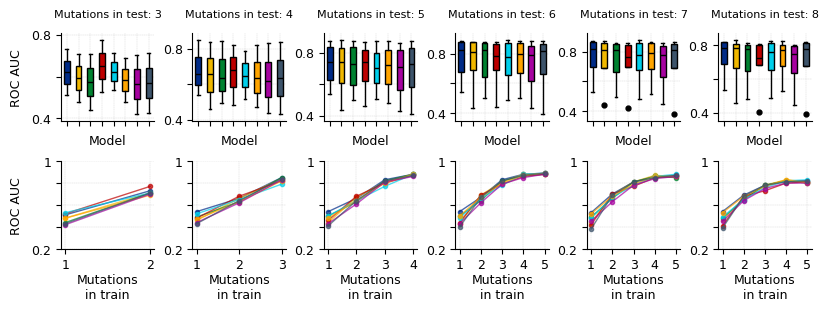

[0.04984967 0.03194039 0.03883599 0.02769926 0.07508182]
#########################
[0 1]
261    0.69
252    0.73
Name: precision, dtype: float64
#########################
#########################
[0 1]
202    0.69
193    0.74
Name: precision, dtype: float64
#########################
#########################
[0 1]
97    0.69
76    0.73
Name: precision, dtype: float64
#########################
#########################
[0 1]
211    0.69
219    0.74
Name: precision, dtype: float64
#########################
#########################
[0 1]
1     0.69
27    0.74
Name: precision, dtype: float64
#########################
#########################
[0 1]
49    0.69
62    0.74
Name: precision, dtype: float64
#########################
#########################
[0 1]
120    0.69
105    0.74
Name: precision, dtype: float64
#########################
#########################
[0 1]
162    0.69
146    0.74
Name: precision, dtype: float64
#########################
[0.04984967 0.03194039 0.03883599 0.0

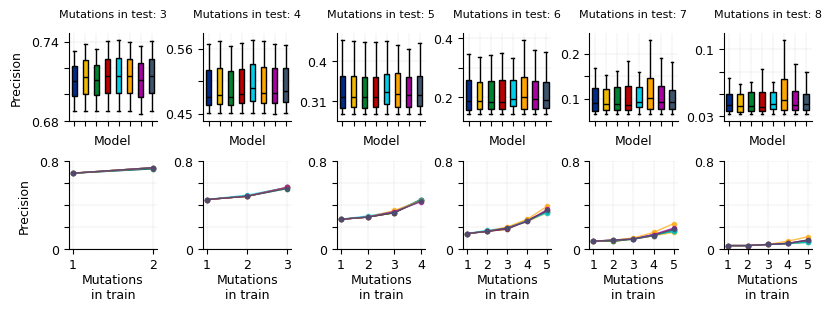

[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]
#########################
[0 1]
261    0.81
252    0.84
Name: f1, dtype: float64
#########################
#########################
[0 1]
202    0.81
193    0.84
Name: f1, dtype: float64
#########################
#########################
[0 1]
97    0.81
76    0.83
Name: f1, dtype: float64
#########################
#########################
[0 1]
211    0.81
219    0.84
Name: f1, dtype: float64
#########################
#########################
[0 1]
1     0.81
27    0.83
Name: f1, dtype: float64
#########################
#########################
[0 1]
49    0.81
62    0.84
Name: f1, dtype: float64
#########################
#########################
[0 1]
120    0.81
105    0.83
Name: f1, dtype: float64
#########################
#########################
[0 1]
162    0.81
146    0.84
Name: f1, dtype: float64
#########################
[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]
#########################
[0 1 2]
26

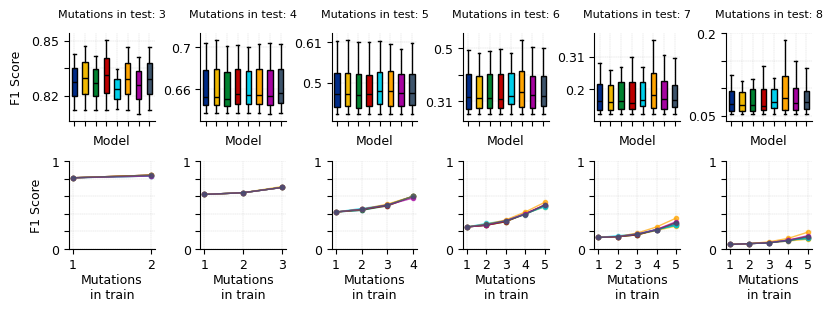

[0.54775782 0.2202531  0.37121053 0.02770776 0.74050445]
#########################
[0 1]
261    0.69
252    0.74
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
202    0.69
193    0.74
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
97    0.69
76    0.74
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
211    0.69
219    0.75
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
1     0.69
27    0.73
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
49    0.69
62    0.74
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
120    0.69
105    0.74
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
162    0.69
146    0.74
Name: accuracy, dtype: float64
#########################
[0.54775782 0.2202531  0.37121053 0.02770776 

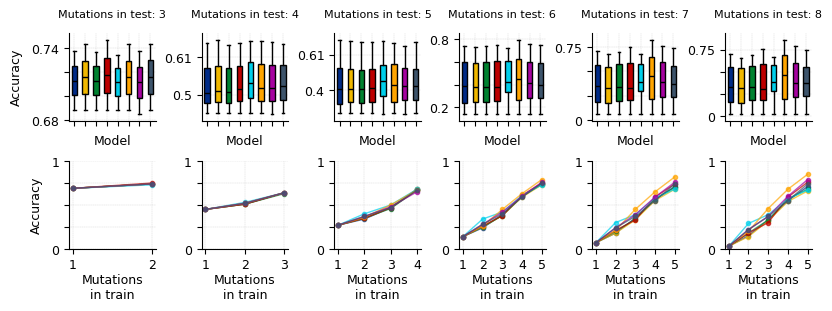

[0.84865719 0.92638231 0.91374408 1.         0.73933649]
#########################
[0 1]
261    1.00
252    0.97
Name: recall, dtype: float64
#########################
#########################
[0 1]
202    1.00
193    0.97
Name: recall, dtype: float64
#########################
#########################
[0 1]
97    1.00
76    0.97
Name: recall, dtype: float64
#########################
#########################
[0 1]
211    1.00
219    0.97
Name: recall, dtype: float64
#########################
#########################
[0 1]
1     1.00
27    0.94
Name: recall, dtype: float64
#########################
#########################
[0 1]
49    1.00
62    0.96
Name: recall, dtype: float64
#########################
#########################
[0 1]
120    1.00
105    0.96
Name: recall, dtype: float64
#########################
#########################
[0 1]
162    1.00
146    0.96
Name: recall, dtype: float64
#########################
[0.84865719 0.92638231 0.91374408 1.         0.73933649]
####

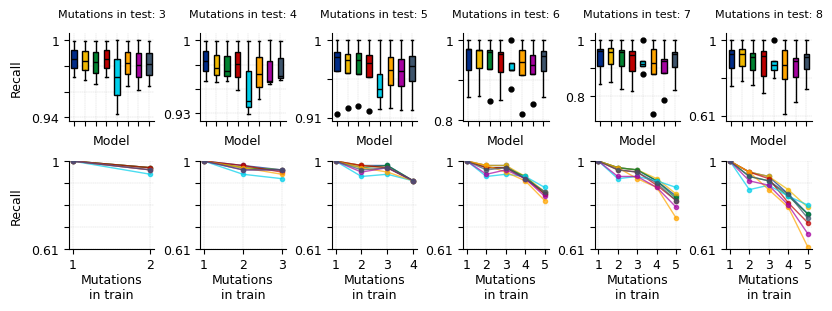

#########################
[0 1]
261    0.35
252    0.89
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
202    0.73
193    0.86
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
97    0.52
76    0.84
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
211    0.60
219    0.96
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
1     0.72
27    0.91
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
49    0.55
62    0.76
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
120    0.62
105    0.86
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
162    0.45
146    0.94
Name: top_100_pct, dtype: float64
#########################
[[0.01785714 0.98214286]
 [0.1209564  0.8790436 ]
 [0.31449237 0.68550763]
 [0

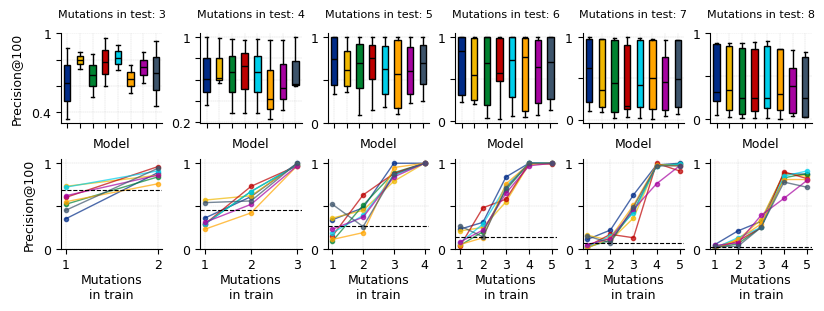


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv
Reading CSV file

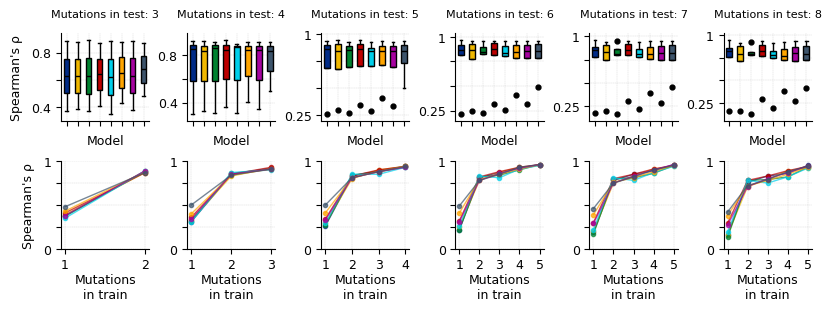


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv


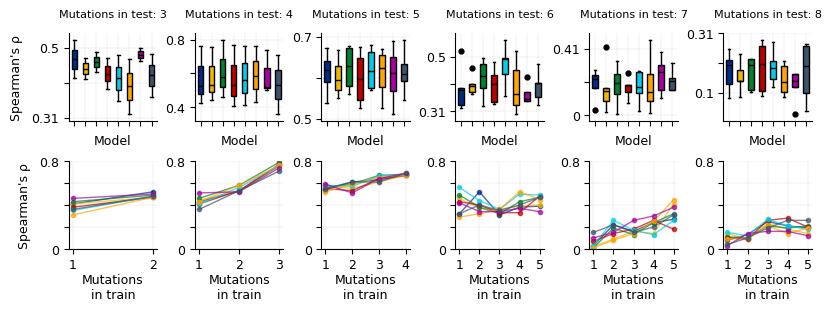


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_evaluation_tra

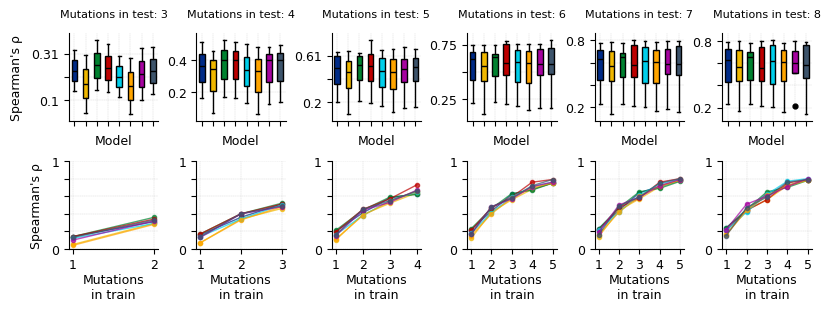


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_evalua

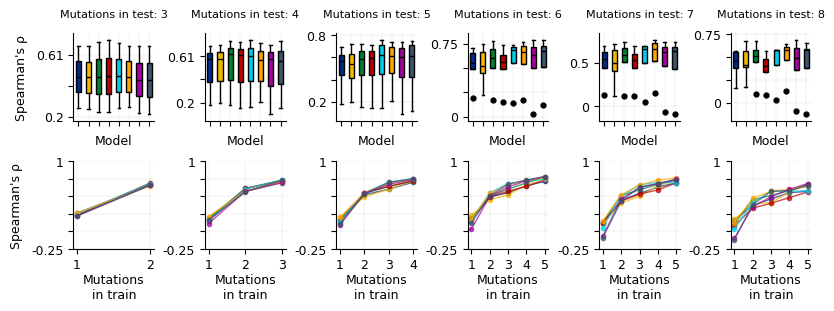

In [7]:
pred_begin = 1
min_muts = 3
n_muts_to_check = 6


for dataset_name in ["gfp", "lov", "pard3", "his", "casp"]:
    var_to_use = var_to_use_dict[dataset_name]
    embedding_base_dir = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/%s/%s_regression_optimal" % (dataset_name, dataset_name)
    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)

    for feature_to_plot in var_to_use:
        plot_mutation_model_performance(
            color_map,
            df_all,
            pred_begin,
            min_muts,
            n_muts_to_check,
            feature_to_plot,
            gfp_muts if (dataset_name == "gfp" and feature_to_plot == "top_100_pct") else None,
            output_dir="./refined_figures/figure_models_comparision/%s/" % dataset_name,
            min_max_y=True
        )

In [8]:
df_all

,correlation,p_value,test_mutations,train_mutations,classifier,model_name,clf_type,model
0,0.739987,0.000000e+00,6,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
1,0.686927,9.574517e-56,7,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
2,0.576417,8.801636e-28,8,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
3,0.536801,3.418123e-18,9,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
4,0.473438,1.344075e-10,10,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_3b,mlp,esm_3b
...,...,...,...,...,...,...,...,...
275,0.660914,6.257654e-297,6,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m
276,0.650150,3.202158e-48,7,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m
277,0.564941,1.591064e-26,8,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m
278,0.517111,8.728977e-17,9,4,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_35m,mlp,esm_35m


In [9]:
#filtered_df_all["model_name"].unique()

filtered_df_all = df_all[df_all["test_mutations"] <= 8]


filtered_df_all["scale"] = np.nan

for model_name in filtered_df_all["model_name"].unique():
    filtered_df_all.loc[filtered_df_all["model_name"] == model_name, "scale"] = discretized_parameter_scale[model_name]


var_explained_factor_results = []

for tm in range(3, 9):
    sub_df = filtered_df_all[(filtered_df_all["test_mutations"] == tm) & (filtered_df_all["train_mutations"] >= 1)]
    ss_all, results_df = calculate_ss_for_df_and_factors(
        sub_df,
        factors=["model_name", "train_mutations", "scale"],
        variables_to_calculate=var_to_use
    )

    for var in var_to_use:#
        for factor in ["model_name", "train_mutations", "scale"]:
            ss_factor_for_var = results_df[(results_df["factor_name"] == factor) & (results_df["var"] == var)]["SS"].sum()
            total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]
            

            var_explained_factor_results.append({"var": var, 
                                                 "factor": factor, 
                                                 "test_mutations": tm, 
                                                 "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()})

var_explained_factor_df = pd.DataFrame(var_explained_factor_results)

/tmp/ipykernel_2871686/2290975150.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_all["scale"] = np.nan


In [10]:

# output_dir = "./figures/figure_2"
# os.makedirs(output_dir, exist_ok=True)

# for var in var_explained_factor_df['var'].unique():
#     plot_df = var_explained_factor_df[var_explained_factor_df['var'] == var].copy()
#     # Sort/order factors for bar plot
#     factor_order = []
#     if "model_name" in plot_df['factor'].values:
#         factor_order.append("model_name")
#     if "scale" in plot_df['factor'].values:
#         factor_order.append("scale")
#     if "train_mutations" in plot_df['factor'].values:
#         factor_order.append("train_mutations")
#     factor_order += [f for f in plot_df['factor'].unique() if f not in factor_order]
#     # Get mean per factor for bar heights
#     means = [plot_df[plot_df['factor'] == f]['var_explained'].mean() for f in factor_order]
#     stds = [plot_df[plot_df['factor'] == f]['var_explained'].std() for f in factor_order]
#     means = np.array(means)
#     stds = np.array(stds)
#     leftover = 1.0 - means
#     leftover = np.clip(leftover, 0, 1)
#     x = np.arange(len(factor_order))
#     xlabels = [xlabel_dict.get(f, f) for f in factor_order]

#     # --- Bar plot (original) ---
#     fig, ax = plt.subplots(figsize=(1.5, 2))
#     bar1 = ax.bar(x, means, color="skyblue", edgecolor="k", label='Explained')
#     bar2 = ax.bar(x, leftover, bottom=means, color="lightgray", edgecolor="k", label='Unexplained')

#     ax.set_xticks(x)
#     ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)
#     ax.set_ylabel("Variance explained", fontsize=label_fontsize)
#     ax.set_title(ylabel_dict[var], fontsize=title_fontsize)
#     ax.tick_params(axis='y', labelsize=tick_fontsize)
#     ax.set_ylim(0, 1.01)
#     #ax.legend(fontsize=legend_fontsize, frameon=False, loc="lower left", bbox_to_anchor=(0,1.01), ncol=2)
#     plt.tight_layout()
#     #plt.savefig(os.path.join(output_dir, f"var_explained_gfp_{var}_bars.svg"), bbox_inches='tight')
#     plt.show()
#     plt.close()

#     # --- Side-by-side scatter + error bars for factors, colored, no label as x-axis ---
#     fig, ax = plt.subplots(figsize=(2.5, 2.2))
#     # Choose colors to distinguish factors
#     color_palette = ["#1976D2", "#FB8C00", "#43A047", "#8E24AA", "#D32F2F", "#00838F"]
#     # Make sure there are enough colors
#     factor_colors = {f: color_palette[i % len(color_palette)] for i, f in enumerate(factor_order)}
#     # Place all factors at nearly the same x location, but spread a tiny bit to not overlap
#     x_center = 0.55
#     sep = 0.08  # How much to spread the (n) factors horizontally
#     factor_xs = {f: x_center + sep*(i - (len(factor_order)-1)/2) for i, f in enumerate(factor_order)}
#     # Scatter: plot values for each factor, at slightly displaced x, color-coded
#     for i, f in enumerate(factor_order):
#         yvals = plot_df[plot_df['factor'] == f]['var_explained'].values
#         if len(yvals) > 0:
#             xvals = np.random.normal(loc=factor_xs[f], scale=sep/4, size=len(yvals))
#             ax.scatter(xvals, yvals, color=factor_colors[f], alpha=0.25, s=22, zorder=1)
#     # Means + errbars
#     for i, (f, mean, std) in enumerate(zip(factor_order, means, stds)):
#         ax.errorbar(factor_xs[f], mean, yerr=std, fmt='o', 
#                     color=factor_colors[f], elinewidth=2, capsize=5, markersize=8, zorder=2)
#     # The x-axis is just a dummy, no labels
#     ax.set_xlim(x_center - sep*len(factor_order)/1.5, x_center + sep*len(factor_order)/1.5)
#     ax.set_xticks([])
#     # Custom legend mapping color to factor (using dots)
#     for i, f in enumerate(factor_order):
#         ax.scatter([], [], color=factor_colors[f], label=xlabel_dict.get(f, f), s=40)
#     ax.legend(fontsize=legend_fontsize, frameon=False, loc="best", handletextpad=0.5, borderpad=0.5)
#     ax.set_ylabel("Variance explained", fontsize=label_fontsize)
#     ax.set_title(ylabel_dict[var], fontsize=title_fontsize)
#     ax.tick_params(axis='y', labelsize=tick_fontsize)
#     ax.set_ylim(0, 1.01)
#     plt.tight_layout()
#     plt.show()
#     plt.close()

#     # # Magnified/delta bar plot: show how much each factor's mean is above the minimum
#     # deltas = means - np.min(means)
#     # fig, ax = plt.subplots(figsize=(2.2, 2))
#     # bar1 = ax.bar(x, deltas, color="orange", edgecolor="k", label='Δ from min')
#     # for idx, val in enumerate(deltas):
#     #     ax.text(x[idx], val + 0.001, f"{val:.4f}", ha='center', va='bottom', fontsize=6)
#     # ax.set_xticks(x)
#     # ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)
#     # ax.set_ylabel("Variance explained (Δ from min)", fontsize=label_fontsize)
#     # ax.set_title(ylabel_dict[var] + " (Δ from min)", fontsize=title_fontsize)
#     # ax.tick_params(axis='y', labelsize=tick_fontsize)
#     # ax.set_ylim(0, max(0.011, np.max(deltas)*1.15))
#     # plt.tight_layout()
#     # #plt.savefig(os.path.join(output_dir, f"var_explained_gfp_{var}_bars_delta.svg"), bbox_inches='tight')
#     # plt.show()
#     # plt.close()


In [11]:
best_embedding_df = []

for j in range(1, 6):
    for i in range(j+1, 11):
    
        df = df_all[(df_all["test_mutations"] == i) & (df_all["train_mutations"] == j)]
        max_df = df.max().to_frame().T
        max_df["model_name"] = "llm"
        #max_df = df[df["model_name"] == "esm_35m"]
       # max_df["model_name"] = "llm"
        best_embedding_df.append(max_df)

#best_embedding_df = pd.concat(best_embedding_df)
best_embedding_df = df_all[df_all["model_name"] == "esm_35m"]
best_embedding_df["model_name"] = "llm"


ohe_embedding_df_all = pd.concat([best_embedding_df, ohe_df_all])
#ohe_embedding_df_all


/tmp/ipykernel_2871686/2546260449.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"



Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2-sma

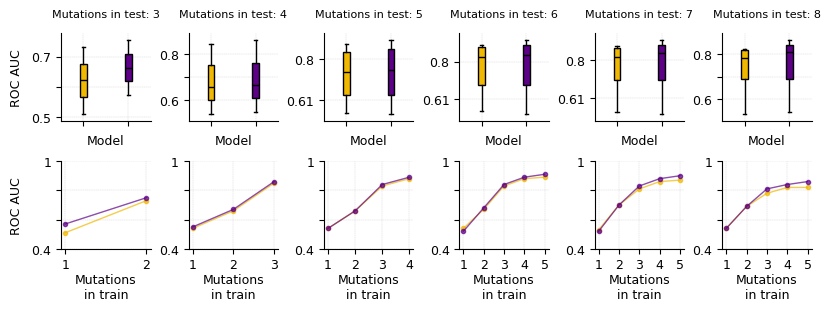

Feature to plot: precision, Max model: progen2-small, gfp
progen2-small
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
#########################
[0 1]
49    0.69
62    0.74
Name: precision, dtype: float64
#########################
#########################
[0 1]
19    0.69
27    0.73
Name: precision, dtype: float64
#########################
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
#########################
[0 1 2]
50    0.45
63    0.48
41    0.56
Name: precision, dtype: float64
#########################
#########################
[0 1 2]
20    0.45
28    0.48
0     0.73
Name: precision, dtype: float64
#########################
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
#########################
[0 1 2 3]
51    0.27
64    0.29
42    0.35
35    0.44
Name: precision, dtype: float64
#########################
#########################
[0 1 2 3]
21    0.27
29    0.29
1     0.62
12    0.78
Name: precision, dtype: float64
#########################
[0.5485

/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


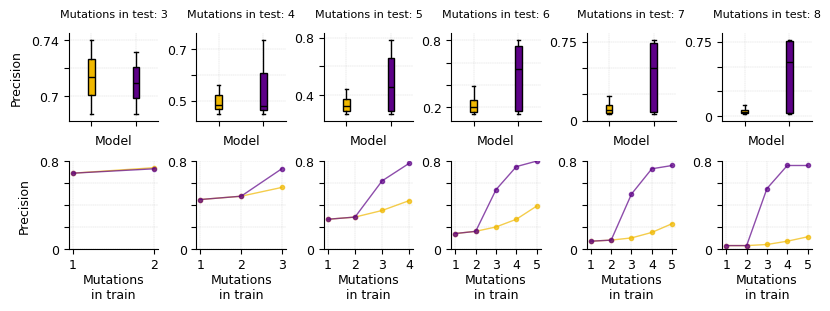

Feature to plot: f1, Max model: progen2-small, gfp
progen2-small
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
#########################
[0 1]
49    0.81
62    0.84
Name: f1, dtype: float64
#########################
#########################
[0 1]
19    0.81
27    0.83
Name: f1, dtype: float64
#########################
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
#########################
[0 1 2]
50    0.62
63    0.64
41    0.70
Name: f1, dtype: float64
#########################
#########################
[0 1 2]
20    0.62
28    0.64
0     0.76
Name: f1, dtype: float64
#########################
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
#########################
[0 1 2 3]
51    0.42
64    0.45
42    0.51
35    0.60
Name: f1, dtype: float64
#########################
#########################
[0 1 2 3]
21    0.42
29    0.45
1     0.61
12    0.68
Name: f1, dtype: float64
#########################
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]

/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


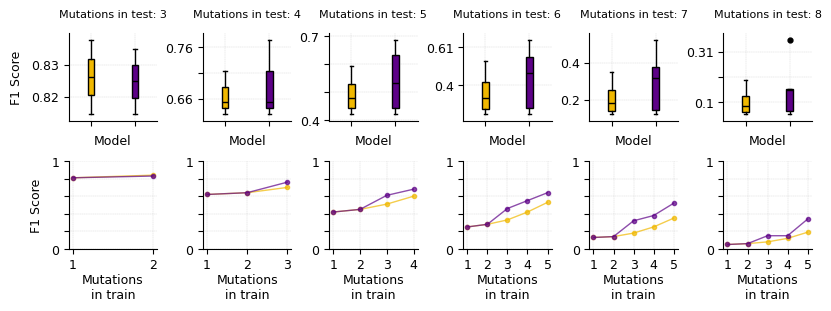

Feature to plot: accuracy, Max model: progen2-small, gfp
progen2-small
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
#########################
[0 1]
49    0.69
62    0.74
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
19    0.69
27    0.74
Name: accuracy, dtype: float64
#########################
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
#########################
[0 1 2]
50    0.45
63    0.52
41    0.64
Name: accuracy, dtype: float64
#########################
#########################
[0 1 2]
20    0.45
28    0.52
0     0.78
Name: accuracy, dtype: float64
#########################


/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
#########################
[0 1 2 3]
51    0.27
64    0.36
42    0.50
35    0.67
Name: accuracy, dtype: float64
#########################
#########################
[0 1 2 3]
21    0.27
29    0.37
1     0.79
12    0.85
Name: accuracy, dtype: float64
#########################
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
#########################
[0 1 2 3 4]
52    0.14
65    0.26
43    0.45
36    0.63
57    0.79
Name: accuracy, dtype: float64
#########################
#########################
[0 1 2 3 4]
22    0.14
30    0.29
2     0.87
13    0.90
7     0.91
Name: accuracy, dtype: float64
#########################
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
#########################
[0 1 2 3 4]
53    0.07
66    0.21
44    0.45
37    0.65
58    0.82
Name: accuracy, dtype: float64
#########################
#########################
[0 1 2 3 4]
23    0.07
31    0.25
3     0.93
14    0.94
8     0.95
Name: accura

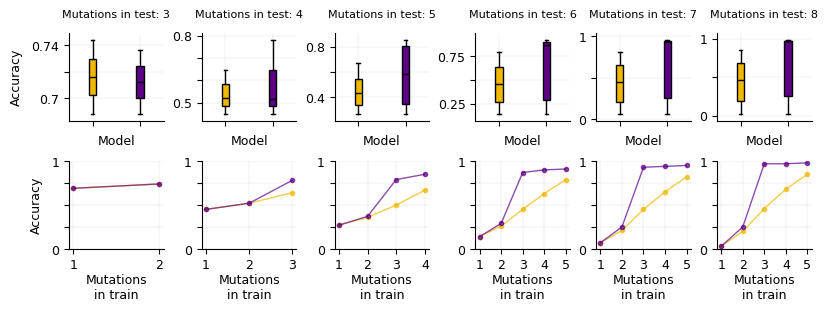

Feature to plot: recall, Max model: esm_8m, gfp
esm_8m
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
#########################
[0 1]
261    1.00
252    0.97
Name: recall, dtype: float64
#########################
#########################
[0 1]
19    1.00
27    0.97
Name: recall, dtype: float64
#########################
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
#########################
[0 1 2]
262    1.00
253    0.98
245    0.96
Name: recall, dtype: float64
#########################
#########################
[0 1 2]
20    1.00
28    0.97
0     0.79
Name: recall, dtype: float64
#########################
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
#########################
[0 1 2 3]
263    1.00
254    0.98
246    0.98
269    0.91
Name: recall, dtype: float64
#########################
#########################
[0 1 2 3]
21    1.00
29    0.97
1     0.61
12    0.61
Name: recall, dtype: float64
#########################
[0.08562401 0.22243286 0.08309637

/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


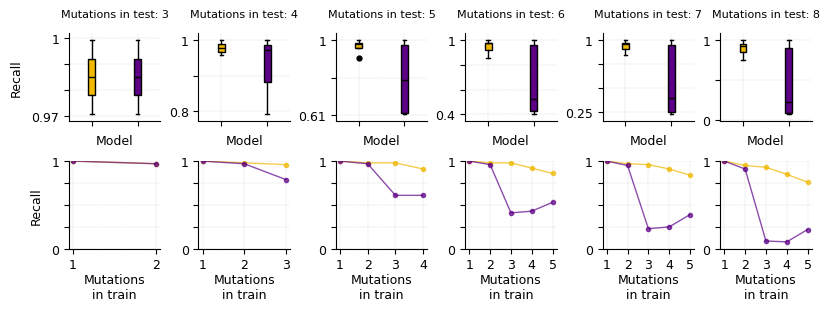

Feature to plot: top_100_pct, Max model: esm_650m, gfp
esm_650m
#########################
[0 1]
211    0.60
219    0.96
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
19    0.84
27    0.97
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2]
212    0.29
220    0.73
238    0.97
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2]
20    0.46
28    0.70
0     1.00
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2 3]
213    0.15
221    0.63
239    0.88
232    1.00
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2 3]
21    0.26
29    0.67
1     1.00
12    1.00
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2 3 4]
214    0.03
222    0.48
240    0.58
233    1.00
227    0.99
Name: top_100_pct, dtype: float64
#########################
#######

/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


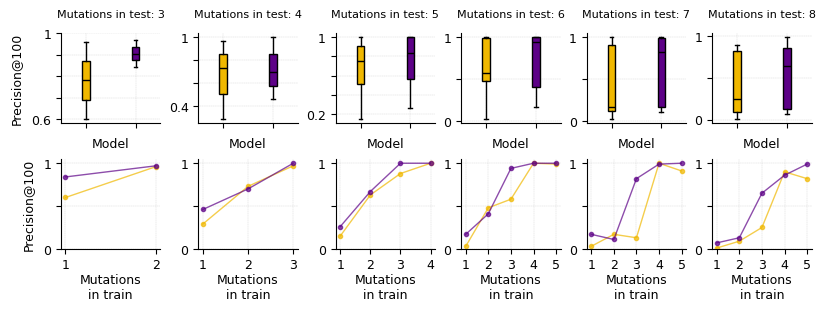


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv
Reading CSV file

/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


[0.91427613 0.96544235 0.94034808 0.30968795 0.80545723]
#########################
[0 1]
36    0.41
44    0.87
Name: correlation, dtype: float64
#########################
#########################
[0 1]
19    0.49
27    0.91
Name: correlation, dtype: float64
#########################
[0.91427613 0.96544235 0.94034808 0.30968795 0.80545723]
#########################
[0 1 2]
37    0.36
45    0.85
63    0.93
Name: correlation, dtype: float64
#########################
#########################
[0 1 2]
20    0.44
28    0.89
0     0.94
Name: correlation, dtype: float64
#########################
[0.91427613 0.96544235 0.94034808 0.30968795 0.80545723]
#########################
[0 1 2 3]
38    0.34
46    0.83
64    0.90
57    0.94
Name: correlation, dtype: float64
#########################
#########################
[0 1 2 3]
21    0.41
29    0.87
1     0.94
12    0.96
Name: correlation, dtype: float64
#########################
[0.91427613 0.96544235 0.94034808 0.30968795 0.80545723]
##########

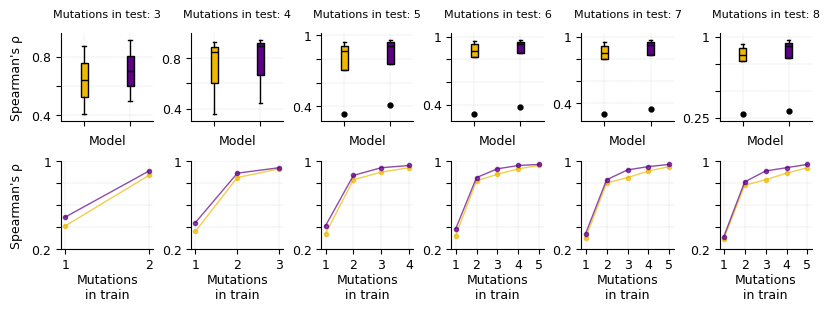


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv


/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


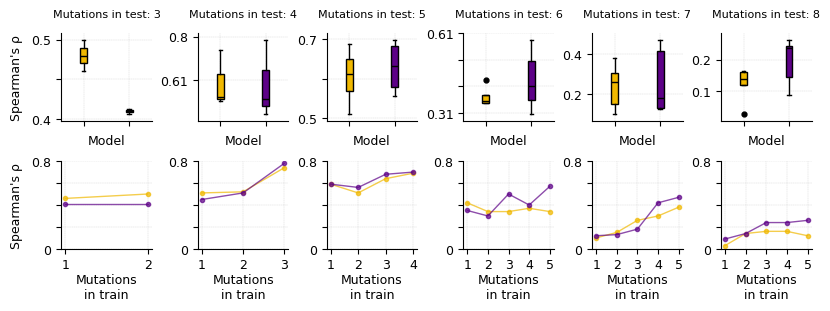


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/his/his_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_evaluation_tra

/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


[0.69374473 0.83454608 0.75205459 0.19801913 0.53223333]
#########################
[0 1]
184    0.10
175    0.32
Name: correlation, dtype: float64
#########################
#########################
[0 1]
19    0.16
27    0.37
Name: correlation, dtype: float64
#########################
[0.69374473 0.83454608 0.75205459 0.19801913 0.53223333]
#########################
[0 1 2]
185    0.13
176    0.40
198    0.48
Name: correlation, dtype: float64
#########################
#########################
[0 1 2]
20    0.17
28    0.43
0     0.53
Name: correlation, dtype: float64
#########################
[0.69374473 0.83454608 0.75205459 0.19801913 0.53223333]
#########################
[0 1 2 3]
186    0.15
177    0.44
199    0.53
192    0.67
Name: correlation, dtype: float64
#########################
#########################
[0 1 2 3]
21    0.18
29    0.49
1     0.62
12    0.65
Name: correlation, dtype: float64
#########################
[0.69374473 0.83454608 0.75205459 0.19801913 0.53223333]
#

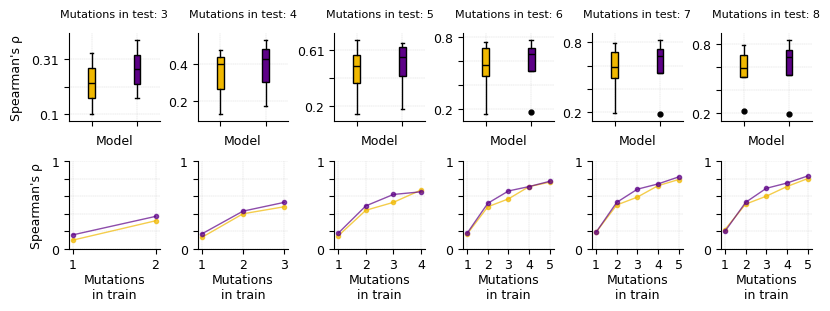


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_5_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_2_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_4_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_3b_evaluation_train_on_3_mlp.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/casp/casp_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1_mlp.csv
Reading CSV file: esm_650m_evaluation_train_on_3_mlp.csv
Reading CSV file: esm_650m_evalua

/tmp/ipykernel_2871686/675938131.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


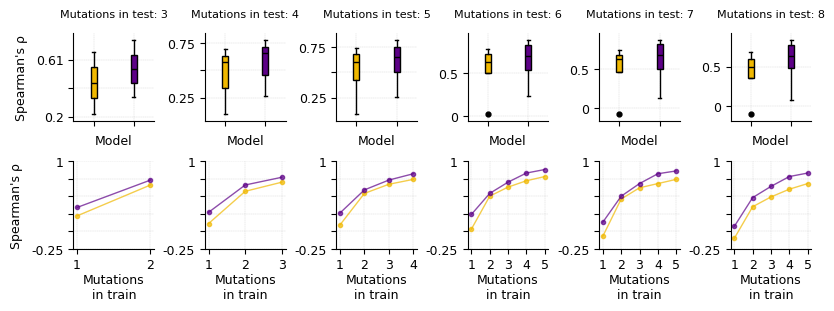

In [12]:
color_map = {
    "llm": "#f0b800",
    "ohe": "#5d0187",
}


pred_begin = 1
min_muts = 3
n_muts_to_check = 6



max_model_df = []
for dataset_name in ["gfp", "lov", "pard3", "his", "casp"]:
    var_to_use = var_to_use_dict[dataset_name]
    embedding_base_dir = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/%s/%s_regression_optimal" % (dataset_name, dataset_name)
    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)

    var_to_use = var_to_use_dict[dataset_name]

    for feature_to_plot in var_to_use:

        mean_correlations = df_all.groupby("model_name")[feature_to_plot].median()
        max_model = mean_correlations.idxmax()
        print("Feature to plot: %s, Max model: %s, %s" % (feature_to_plot, max_model, dataset_name))

        max_model_df.append({
            "model_name": max_model,
            "feature": feature_to_plot,
            "dataset": dataset_name
        })
        
        print(max_model)
        best_embedding_df = df_all[df_all["model_name"] == max_model]
        best_embedding_df["model_name"] = "llm"
        ohe_embedding_df_all = pd.concat([best_embedding_df, ohe_df_all])

        ohe_embedding_df_all[feature_to_plot] = ohe_embedding_df_all[feature_to_plot].astype(np.float64)
        
        plot_mutation_model_performance(
            color_map,
            ohe_embedding_df_all,
            pred_begin,
            min_muts,
            n_muts_to_check,
            feature_to_plot,
            min_max_y=True,
            output_dir="./refined_figures/figure_ohe_vs_llm/%s/" % dataset_name,
            #probabilities_by_mutations,
            #output_dir="./figures/figure_3_regular/"
        )

In [13]:
base_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data"
ratio_df = []
epsilon = 10 ** -8
datasets_feature_to_use_dict = {"gfp": ["roc", "precision", "f1", "accuracy", "recall", "top_100_pct"],
"lov": ["correlation"],
"pard3": ["correlation"],
"his": ["correlation"],
"casp": ["correlation"]
 }

for k, v in datasets_feature_to_use_dict.items():

    embedding_base_dir = os.path.join(base_path, k, f"{k}_regression_optimal")

    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)

    for feature_to_plot in v:

        mean_correlations = df_all.groupby("model_name")[feature_to_plot].median()
        max_model = mean_correlations.idxmax()
        best_embedding_df = df_all[df_all["model_name"] == max_model]
        best_embedding_df["model_name"] = "llm"
        ohe_embedding_df_all = pd.concat([best_embedding_df, ohe_df_all])

        for train_mutation in ohe_embedding_df_all["train_mutations"].unique():
            for test_mutation in ohe_embedding_df_all["test_mutations"].unique():        
                sub_df = ohe_embedding_df_all[(ohe_embedding_df_all["train_mutations"] == train_mutation) & (ohe_embedding_df_all["test_mutations"] == test_mutation)]
                
                if len(sub_df) == 0:
                    continue

                ohe_value = sub_df[sub_df["model_name"] == "ohe"][feature_to_plot].item()
                llm_value = sub_df[sub_df["model_name"] == "llm"][feature_to_plot].item()

                if llm_value == 0:
                    continue

                print(ohe_value, llm_value)
                
                ratio_df.append({
                    "train_mutations": train_mutation, 
                    "test_mutations": test_mutation, 
                    "ratio": (ohe_value) / (llm_value ), 
                    "ohe_value": ohe_value, 
                    "llm_value": llm_value,
                    "feature": feature_to_plot,
                    "dataset": k
                })



Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2-sma

/tmp/ipykernel_2871686/1142685052.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"
/tmp/ipykernel_2871686/1142685052.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"
/tmp/ipykernel_2871686/1142685052.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

0.529927260484998 0.4452923353159017
0.4944051711440121 0.41090270430302
0.4417319574788617 0.3607268398290582
0.4088436863989896 0.340459691214842
0.3771768655593481 0.3212184710716414
0.3433753186273474 0.3037589452415963
0.3096879527638006 0.2884238882740072
0.2813301350464382 0.2783679468231353
0.2526281711626299 0.2681121046855904
0.9113414454029248 0.8715041799750066
0.8925022935793819 0.8469757104975252
0.8748253922072209 0.8335643165040417
0.8544890188288116 0.8179381023560109
0.8306509022278803 0.7970651415015628
0.805457232886019 0.7765124687260392
0.7838890302167454 0.7573149616351853
0.7622384561842793 0.7385850287847148
0.9682148122619492 0.9604854112996574
0.96703334448027 0.9506174836593498
0.965442345055562 0.9357173509854492
0.9631528020344264 0.9172214893193787
0.9585565481182388 0.8933893385408329
0.9560421254113132 0.9446037713292929
0.9557413277441372 0.9331638513278742
0.9483116906362334 0.9141654713298488
0.9403480765840432 0.8925441316923571
0.9324213959810728 0

/tmp/ipykernel_2871686/1142685052.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"
/tmp/ipykernel_2871686/1142685052.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"
/tmp/ipykernel_2871686/1142685052.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [14]:
rdf = pd.DataFrame(ratio_df)

In [15]:
nmt_base_path = "%s/nmt/results/by_complexity_and_budget_up_to_11/" % base_path
gcn_base_path = "%s/gcn4/results/by_complexity_and_budget_up_to_8/" % base_path




nmt_sets = load_df_with_budget(nmt_base_path)
nmt_train = [5,6,7,8,9]
nmt_test = [9, 10, 11]

gcn_sets = load_df_with_budget(gcn_base_path)
gcn_train = [3,4,5,6]
gcn_test = [6, 7, 8]

In [16]:



all_datasets = [("nmt", nmt_sets, 0.85),
                ("gcn", gcn_sets, 0.5)]


by_subsamples_df = []
for dataset_name, sets, percentile in all_datasets:

    all_ohe_df_list = []
    all_not_ohe_df_list = []

    for set_name, df in sets.items():
        ohe_df = df[df["model_name"] == "one_hot"]
        not_ohe_df = df[df["model_name"] != "one_hot"]
        all_ohe_df_list.append(ohe_df)
        all_not_ohe_df_list.append(not_ohe_df)
    

    


    all_ohe_df = pd.concat(all_ohe_df_list)
    all_not_ohe_df = pd.concat(all_not_ohe_df_list)
    best_model = all_not_ohe_df.groupby("model_name")["cor_llm"].mean().idxmax()

    max_model_df.append({
        "model_name": best_model,
        "feature": "spearman_rho",
        "dataset": dataset_name
    })
    best_model_df = all_not_ohe_df[all_not_ohe_df["model_name"] == best_model]


    all_ohe_df["cor_llm"] = all_ohe_df["cor_llm"].abs()
    best_model_df["cor_llm"] = best_model_df["cor_llm"].abs()

    ohe_grouped = all_ohe_df.groupby(['set_name', 'max_muts_in_train', 'budget'], as_index=False).quantile(percentile)
    best_model_grouped = best_model_df.groupby(['set_name', 'max_muts_in_train', 'budget'], as_index=False).quantile(percentile)


    llm_value = best_model_grouped["cor_llm"].to_numpy()
    working_indices = llm_value != 0

    ohe_grouped = ohe_grouped[working_indices]
    best_model_grouped = best_model_grouped[working_indices]

    ohe_value = ohe_grouped["cor_llm"].to_numpy()
    llm_value = best_model_grouped["cor_llm"].to_numpy()



    by_subsamples_df.append(pd.DataFrame({
                        "train_mutations": ohe_grouped["max_muts_in_train"].to_numpy(), 
                        "test_mutations": np.array([int(x.split("_")[-1]) for x in ohe_grouped["set_name"].to_list()]), 
                        "ratio": (ohe_value) / (llm_value), 
                        "ohe_value": ohe_value, 
                        "llm_value": llm_value,
                        "feature": np.array(["Spearman's ρ"] * len(ohe_value)),
                   
                        "dataset": np.array([dataset_name] * len(ohe_value))
                    }))



/tmp/ipykernel_2871686/1633803208.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_model_df["cor_llm"] = best_model_df["cor_llm"].abs()
/tmp/ipykernel_2871686/1633803208.py:36: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ohe_grouped = all_ohe_df.groupby(['set_name', 'max_muts_in_train', 'budget'], as_index=False).quantile(percentile)
/tmp/ipykernel_2871686/1633803208.py:37: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeri

In [17]:
# (by_subsamples_df[0][["train_mutations","test_mutations", "ohe_value", "llm_value"]]).to_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/oracle_transfer_learning/nmt_baseline.csv")

In [18]:
# Average the columns for by_subsamples_df[0] grouped by train_mutations and test_mutations
averaged_0 = (
    by_subsamples_df[0][["train_mutations", "test_mutations", "ohe_value", "llm_value"]]
    .groupby(["train_mutations", "test_mutations"], as_index=False)
    .mean(numeric_only=True)
)
averaged_0.to_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/oracle_transfer_learning/nmt_baseline.csv")

In [19]:
ratio_df_all = pd.DataFrame(ratio_df)
ratio_df_all = ratio_df_all[ratio_df_all["test_mutations"] <= 8]
ratio_df_all = pd.concat([ratio_df_all] + by_subsamples_df)


/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

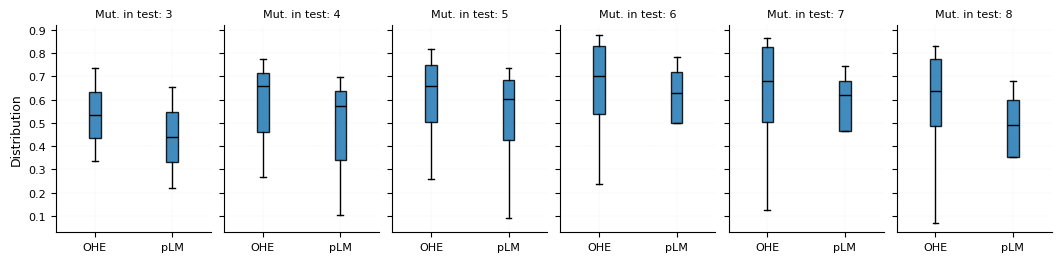

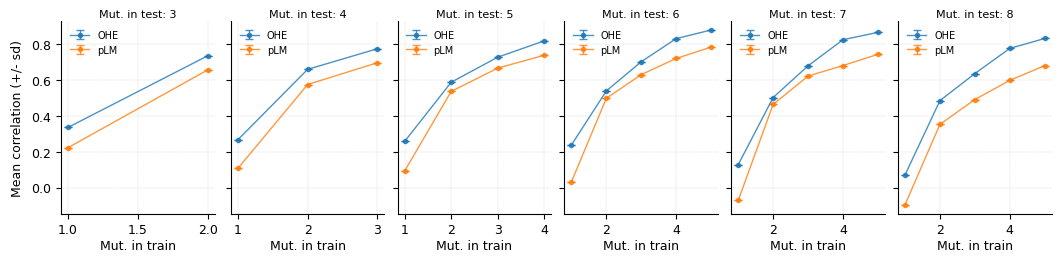

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


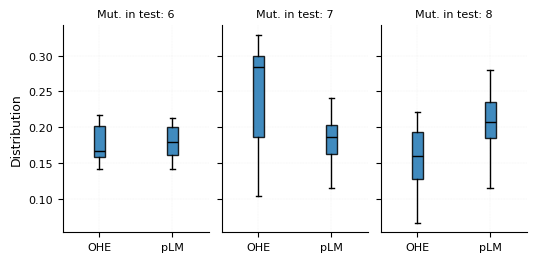

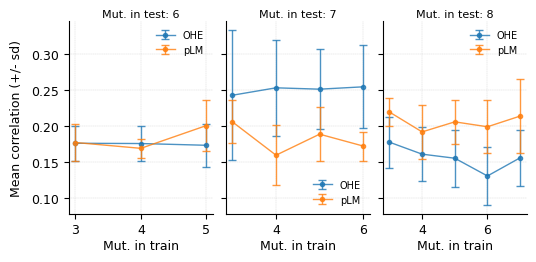

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

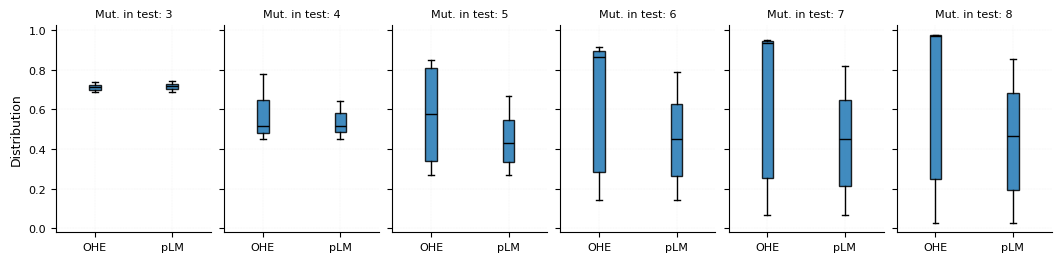

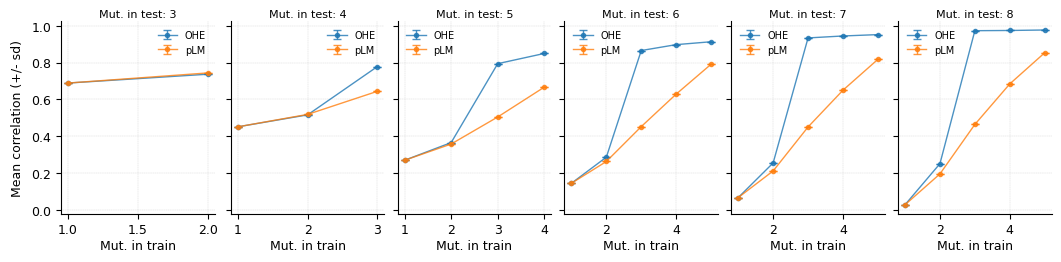

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

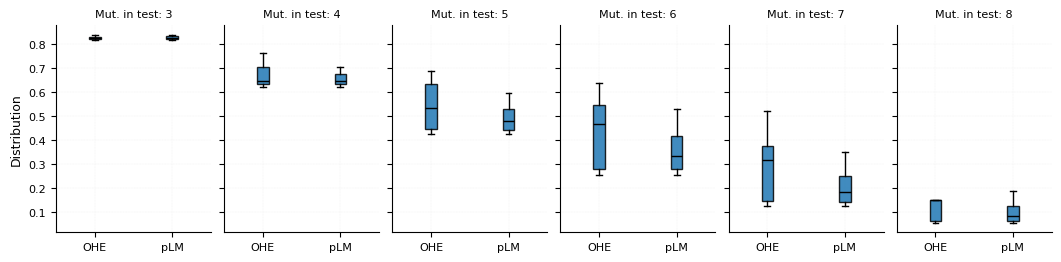

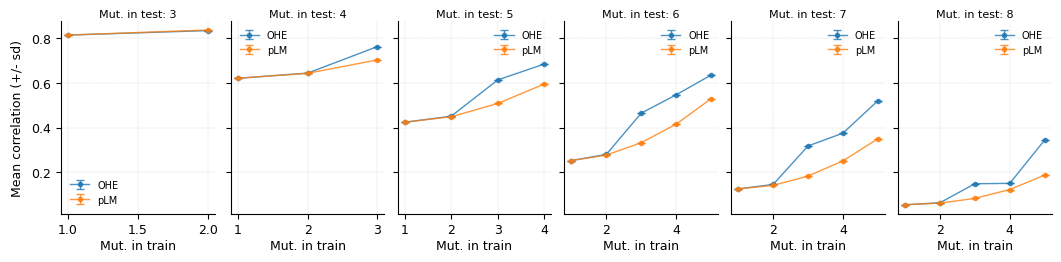

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

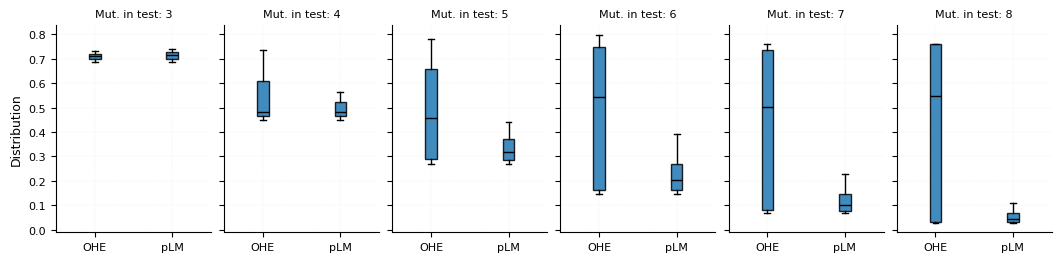

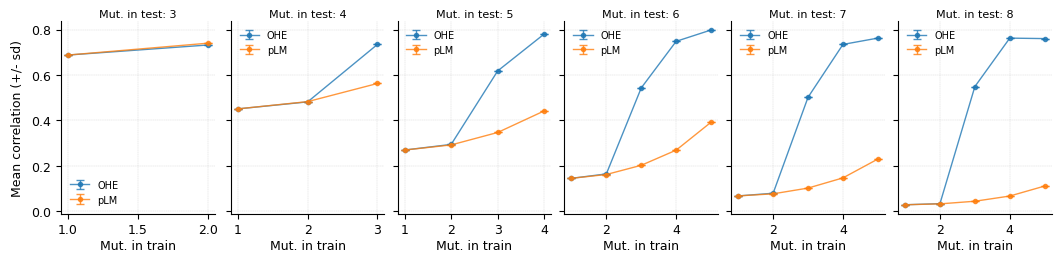

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

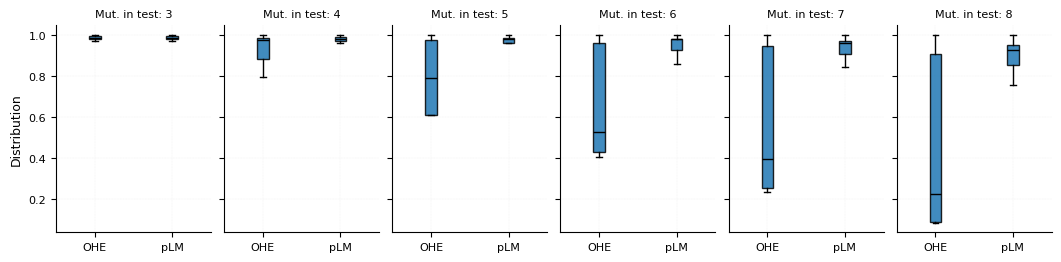

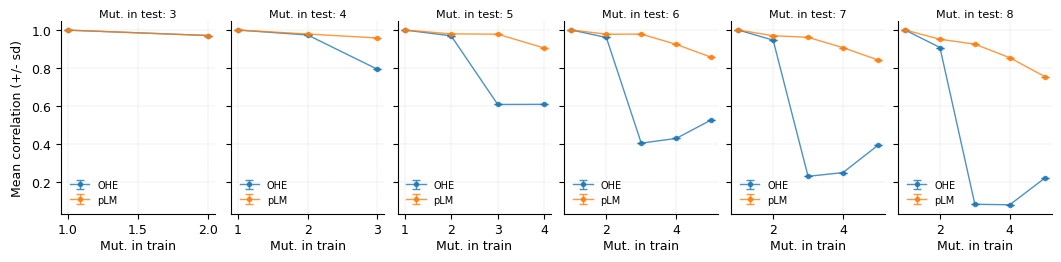

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

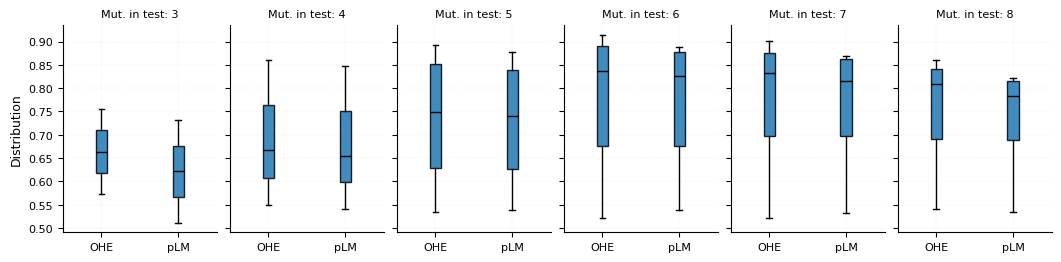

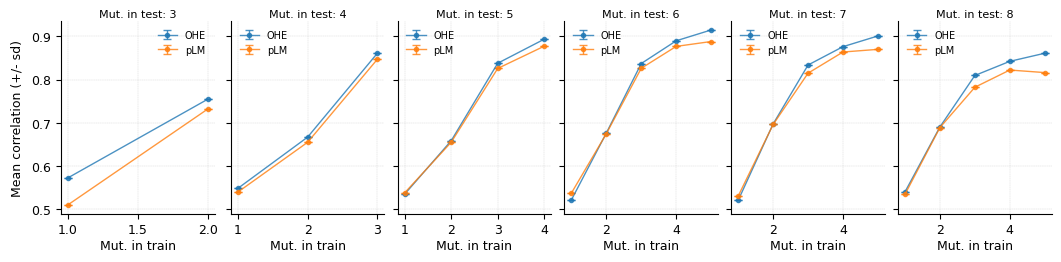

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

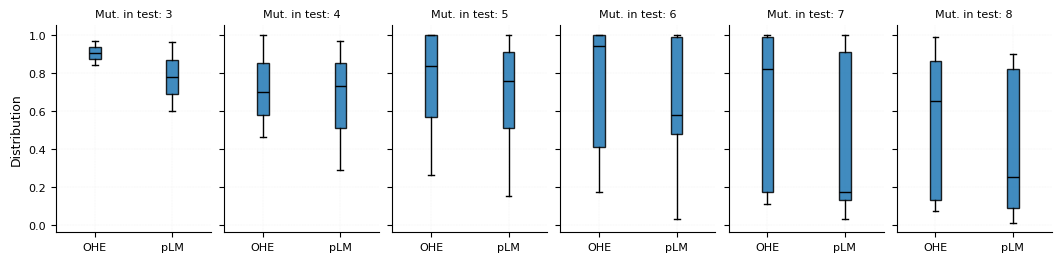

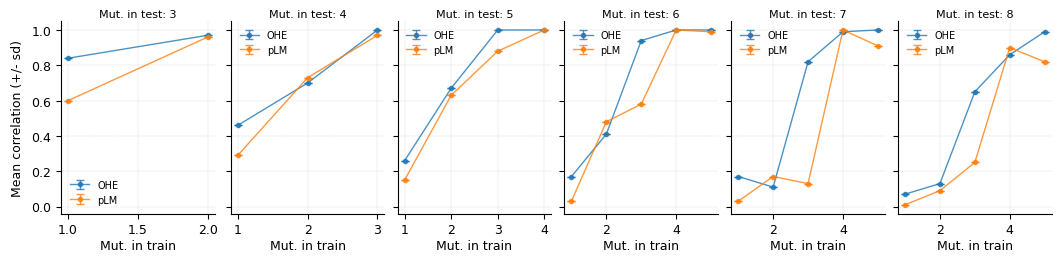

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

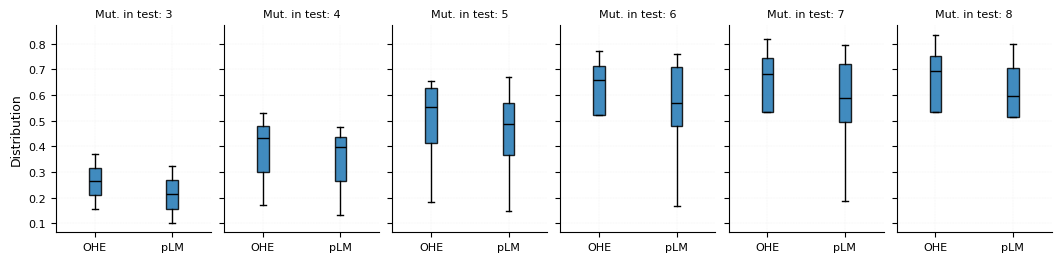

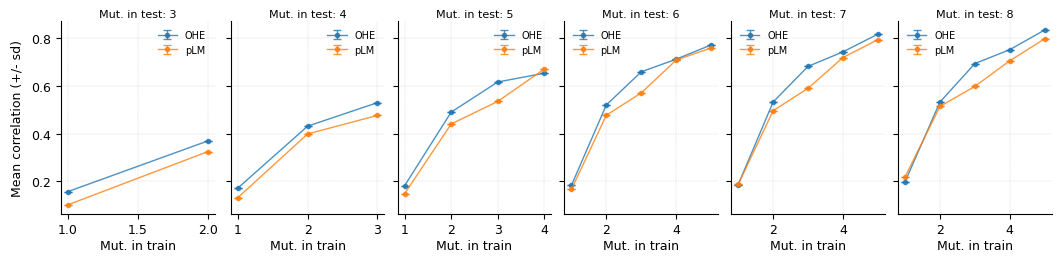

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

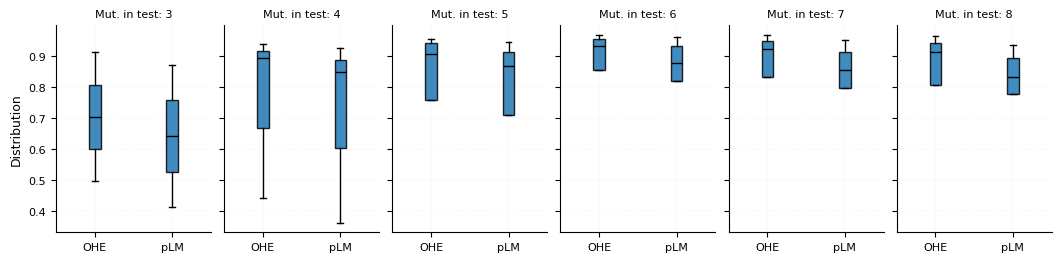

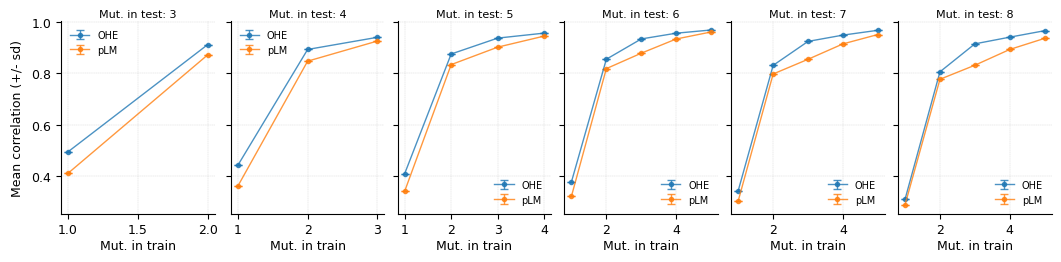

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


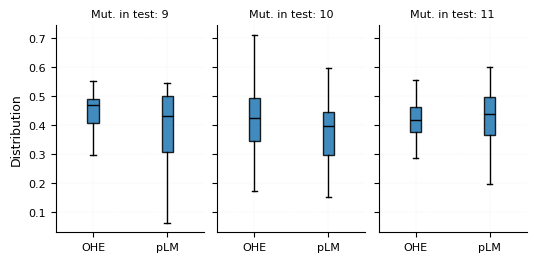

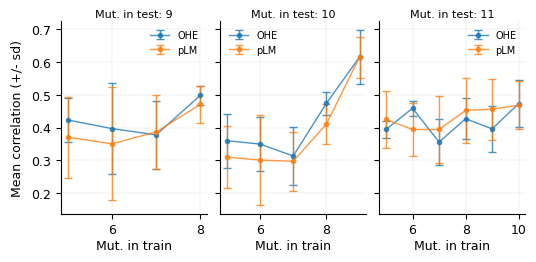

/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2871686/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

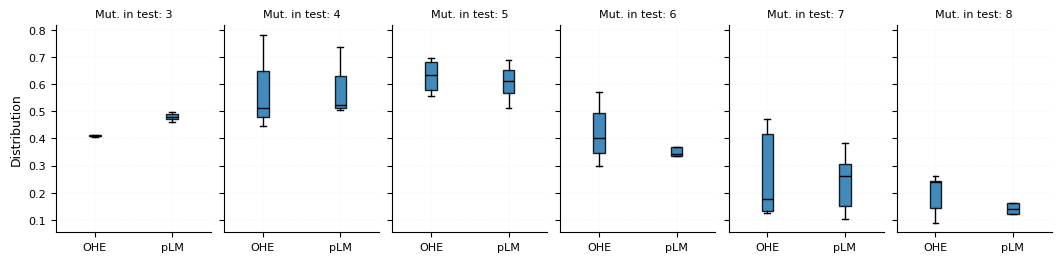

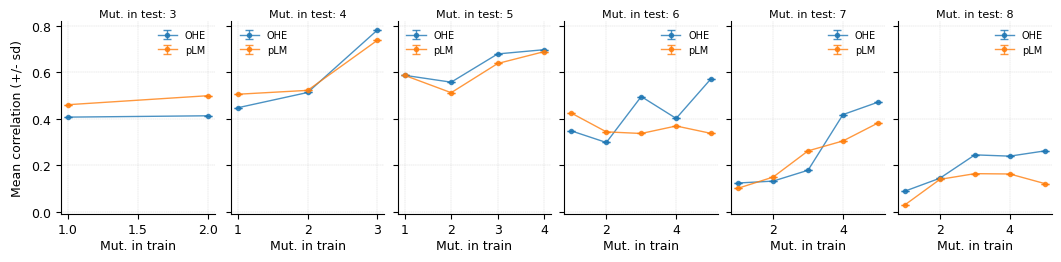

In [20]:

def plot_panel_panel(
    df,
    value_column,
    color_map={'ohe': '#2077B4', 'llm': '#ED594A'},
    plot_type="box",   # "box" or "lines"
    title_fontsize=8,
    label_fontsize=9,
    tick_fontsize=9,
    legend_fontsize=7,
):
    """
    For each unique value in 'test_mutations', creates a subplot in a single row.
    If plot_type == "box", plots a boxplot of value_column for each model, no p-value or t-test.
    If plot_type == "lines", plots the average (+/- sd) of value_column as a function of train_mutations for each model.
    Styling (figsize, fontsize, colors, etc.) is inspired by plot_mutation_model_performance.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    test_mutations_values = sorted(df['test_mutations'].unique())
    test_mutations_values = range(max(3, min(test_mutations_values)), max(test_mutations_values) + 1)
    n_panels = len(test_mutations_values)
    models = df['model'].unique()

    col_size = 1.75  # inspired by plot_mutation_model_performance

    # 1 row: each panel for each test_mutations value
    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(col_size * n_panels, 0.5 + col_size * 1.15),
        constrained_layout=True,
        sharey=True if plot_type=="box" else 'row'
    )

    # If only one panel, axes not an array
    if n_panels == 1:
        axes = np.array([axes])

    for idx, test_mut in enumerate(test_mutations_values):
        ax = axes[idx]
        sub_df = df[df['test_mutations'] == test_mut]

        if plot_type == "box":
            boxplot_data = []
            boxplot_colors = []
            labels = []
            for model in models:
                model_df = sub_df[sub_df['model'] == model]
                boxplot_data.append(model_df[value_column].astype(float).dropna())
                boxplot_colors.append(color_map[model] if model in color_map else None)
                labels.append(str(model))
            # Here, tick_labels is deprecated, use labels instead if using newer matplotlib (>3.9)
            bp = ax.boxplot(
                boxplot_data,
                patch_artist=True,
                labels=labels,
                medianprops=dict(color='black'),
                showfliers=False,
            )
            for patch, color in zip(bp['boxes'], boxplot_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.85)

            ax.grid(True, which='both', linestyle=':', linewidth=0.2, alpha=0.55)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.tick_params(axis='x', labelsize=tick_fontsize - 1)
            ax.tick_params(axis='y', labelsize=tick_fontsize - 1)
            if idx == 0:
                ax.set_ylabel("Distribution", fontsize=label_fontsize)
            ax.set_title(f"Mut. in test: {test_mut}", fontsize=title_fontsize)
            # No legend for boxplot

        elif plot_type == "lines":
            plotted_any = False
            for model in models:
                model_df = sub_df[sub_df['model'] == model]
                if model_df.empty:
                    continue
                avail_train_mut = sorted(model_df['train_mutations'].unique())
                x_vals, y_means, y_sds = [], [], []
                for train_mut in avail_train_mut:
                    if train_mut > test_mut:
                        continue
                    select = model_df[model_df['train_mutations'] == train_mut]
                    if select.empty:
                        continue
                    x_vals.append(train_mut)
                    y = select[value_column].astype(float)
                    y_means.append(np.nanmean(y))
                    y_sds.append(np.nanstd(y))
                if x_vals:
                    color = color_map[model] if model in color_map else None
                    ax.errorbar(
                        x_vals, y_means, yerr=y_sds, marker='o', label=f"{model}",
                        capsize=3, alpha=0.8, color=color, markersize=3, linewidth=1
                    )
                    plotted_any = True

            ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.set_title(f"Mut. in test: {test_mut}", fontsize=title_fontsize, pad=3)
            ax.set_xlabel("Mut. in train", fontsize=label_fontsize, labelpad=2)
            ax.tick_params(axis='x', labelsize=tick_fontsize)
            ax.tick_params(axis='y', labelsize=tick_fontsize)
            if idx == 0:
                ax.set_ylabel(f"Mean {value_column} (+/- sd)", labelpad=6, fontsize=label_fontsize)
            if plotted_any:
                ax.legend(loc='best', fontsize=legend_fontsize, frameon=False)

    plt.show()


ohe_emb_cols = ['correlation', 'test_mutations', 'train_mutations', 'model_name', 'model', 'dataset']

new_ohe_like_dfs = []

for dataset in np.unique(ratio_df_all["dataset"]):
    df_dataset = ratio_df_all[ratio_df_all["dataset"] == dataset]
    for feature in np.unique(df_dataset["feature"]):
        df = df_dataset[df_dataset["feature"] == feature]
        # Make two melted dfs: one for ohe, one for llm

        ohe_llm = []
        for model_type in ["ohe", "llm"]:
            correlation_val = df["ohe_value"].values if model_type == "ohe" else df["llm_value"].values
            temp = pd.DataFrame({
                "correlation": correlation_val,
                "test_mutations": df["test_mutations"].values,
                "train_mutations": df["train_mutations"].values,
                "model_name": ["OHE" if model_type == "ohe" else "pLM"] * len(df),
                "model": ["OHE" if model_type == "ohe" else "pLM"] * len(df),
                "dataset": [dataset] * len(df)
            })
            new_ohe_like_dfs.append(temp)
            ohe_llm.append(temp)
        ohe_llm_df = pd.concat(ohe_llm, ignore_index=True)

        # Example: plot boxplots
        plot_panel_panel(ohe_llm_df, "correlation", color_map=color_map, plot_type="box")
        # Example: plot line plots
        plot_panel_panel(ohe_llm_df, "correlation", color_map=color_map, plot_type="lines")


In [21]:
ratio_df_all.loc[ratio_df_all["dataset"] == "gfp", "dataset"] = "GFP"
ratio_df_all.loc[ratio_df_all["dataset"] == "pard3", "dataset"] = "PARD3"
ratio_df_all.loc[ratio_df_all["dataset"] == "nmt", "dataset"] = "NMT"
ratio_df_all.loc[ratio_df_all["dataset"] == "gcn", "dataset"] = "GCN4"
ratio_df_all.loc[ratio_df_all["dataset"] == "lov", "dataset"] = "LOV"
ratio_df_all.loc[ratio_df_all["dataset"] == "his", "dataset"] = "HIS"
ratio_df_all.loc[ratio_df_all["dataset"] == "casp", "dataset"] = "CASP"
ratio_df_all["title_for_plot"] = [ylabel_dict[k] if k in ylabel_dict.keys() else k for k in ratio_df_all["feature"].to_list()]


In [22]:
ratio_df_all["dataset"].unique()

array(['GFP', 'LOV', 'PARD3', 'HIS', 'CASP', 'NMT', 'GCN4'], dtype=object)

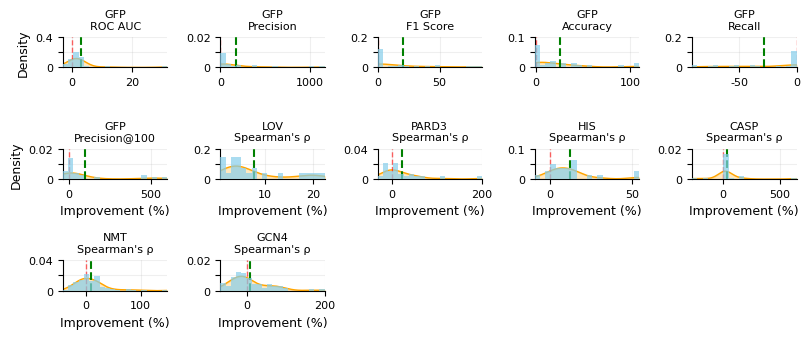

In [23]:

# Iterate over all possible datasets and features in the data for plotting

datasets = ratio_df_all["dataset"].unique()
features = ratio_df_all["feature"].unique()

plot_pairs = []
for dataset in datasets:
    for feature in features:
        subgrp = ratio_df_all[(ratio_df_all["dataset"] == dataset) & (ratio_df_all["feature"] == feature)]
        if len(subgrp) > 0:
            fancy_title = ratio_df_all[(ratio_df_all["dataset"] == dataset) & (ratio_df_all["feature"] == feature)]["title_for_plot"].unique()[0]
            plot_pairs.append((dataset, feature, subgrp, fancy_title))

nplots = len(plot_pairs)
ncols = 5
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.2, 3.5))
axes = axes.flatten()

for i, (dataset, feature, group, fancy_title) in enumerate(plot_pairs):
    ax = axes[i]
    statistic = (group["ratio"] - 1) * 100

    # Plot histogram
    counts, bins, patches = ax.hist(
        statistic, bins=20, color='skyblue', alpha=0.7, density=True, label='Histogram',
        zorder=3
    )

    # Plot KDE
    if len(statistic) > 1:
        xmin, xmax = bins[0], bins[-1]
        x = np.linspace(xmin, xmax, 500)
        kde = stats.gaussian_kde(statistic, bw_method=0.4)
        y = kde(x)
        ax.plot(x, y, color='orange', linewidth=1, label='Density (KDE)', zorder=2)
        ax.fill_between(x, y, color='orange', alpha=0.25, zorder=2)
    else:
        xmin, xmax = ax.get_xlim()

    # Add mean line
    mean_val = np.mean(statistic)
    ax.axvline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
    # Reference line at Zero Improvement
    ax.axvline(0, color="red", linestyle="--", lw=1, alpha=0.6, label="No Improvement")

    ax.set_title(f"{dataset}\n{fancy_title}", fontsize=8)
    if i == 0 or i == 5:
        ax.set_ylabel("Density", fontsize=9)
    else:
        ax.set_ylabel("")
    if i >= ncols:
        ax.set_xlabel("Improvement (%)", fontsize=9)
    else:
        ax.set_xlabel("")

    ax.set_xlim(xmin, xmax)

    fix_ticks(ax, 
              y=True,
              x=False,
              every_other=False,
              fontsize=8)
    
    fix_ticks(ax, 
              y=False,
              x=True,
              every_other=False,
              xlim=[xmin,xmax],
              fontsize=8)

    plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(alpha=0.2)

# Turn off extra axes (if any)
for j in range(len(plot_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/improvement_plot.svg", bbox_inches='tight')
plt.show()

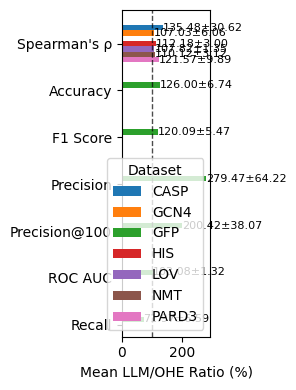

In [24]:

plot_source = ratio_df_all.copy()
plot_source["fancy_title"] = plot_source["title_for_plot"].fillna(plot_source["feature"])

# --- summarize at the exact level being plotted ---
summary_df = (
    plot_source
    .groupby(["dataset", "fancy_title"])["ratio"]
    .agg(["mean", "sem"])
    .reset_index()
    .rename(columns={"mean": "mean_ratio", "sem": "sem_ratio"})
)

# Multiply by 100 to convert to percent
summary_df["mean_ratio"] = summary_df["mean_ratio"] * 100
summary_df["sem_ratio"] = summary_df["sem_ratio"] * 100

# Orders
hue_order = sorted(summary_df["dataset"].dropna().unique())
y_order = list(summary_df["fancy_title"].drop_duplicates())

# Pivot so means and SEMs align exactly
mean_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="mean_ratio")
    .reindex(y_order)
)

sem_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="sem_ratio")
    .reindex(y_order)
)

# --- plot manually ---
fig, ax = plt.subplots(figsize=(3, 4))

n_hue = len(hue_order)
y = np.arange(len(y_order))
total_height = 0.8
bar_height = total_height / max(n_hue, 1)

palette = sns.color_palette("tab10", n_colors=n_hue)

bars = []
labels = []

for i, dataset in enumerate(hue_order):
    offset = (i - (n_hue - 1) / 2) * bar_height

    vals = mean_piv[dataset].to_numpy(dtype=float)
    errs = sem_piv[dataset].to_numpy(dtype=float)

    mask = ~np.isnan(vals)

    bar = ax.barh(
        y[mask] + offset,
        vals[mask],
        height=bar_height,
        #xerr=errs[mask],
        capsize=3,
        color=palette[i],
        label=dataset,
        edgecolor="none"
    )
    bars.append(bar)
    labels.append(dataset)

    # Add ± values as text on each bar
    for j, (yy, val, err) in enumerate(zip(y[mask] + offset, vals[mask], errs[mask])):
        if not np.isnan(val) and not np.isnan(err):
            text = f"{val:.2f}±{err:.2f}"
            # Place text at right end of the bar, a bit to the right if val > 0, else to the left
            xloc = val + 0.02 if val >= 0 else val - 0.02  # Adjust as needed
            ha = "left" if val >= 0 else "right"
            ax.text(xloc, yy, text, va='center', ha=ha, fontsize=8, color="black")

ax.set_yticks(y)
ax.set_yticklabels(y_order)
ax.invert_yaxis()
ax.set_xlabel("Mean LLM/OHE Ratio (%)")
ax.set_ylabel("")
ax.axvline(x=100, color="k", linestyle="--", linewidth=1, alpha=0.7)

# Add legend
ax.legend(title="Dataset", loc="best")

#ax.set_xlim(20, 130)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2871686/3541086354.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


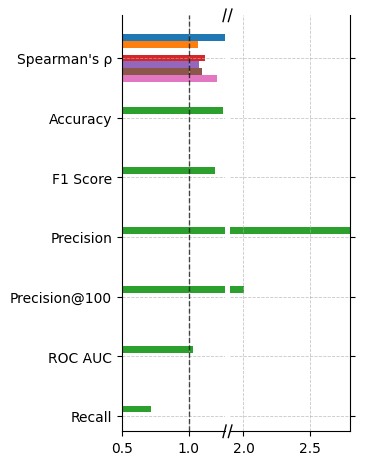

In [25]:

# --- attach title_for_plot at the row level first ---
plot_source = ratio_df_all.copy()
plot_source["fancy_title"] = plot_source["title_for_plot"].fillna(plot_source["feature"])

# --- summarize at the exact level being plotted ---
summary_df = (
    plot_source
    .groupby(["dataset", "fancy_title"])["ratio"]
    .agg(["mean", "sem"])
    .reset_index()
    .rename(columns={"mean": "mean_ratio", "sem": "sem_ratio"})
)

# Orders
hue_order = sorted(summary_df["dataset"].dropna().unique())
y_order = list(summary_df["fancy_title"].drop_duplicates())

# Pivot so means and SEMs align exactly
mean_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="mean_ratio")
    .reindex(y_order)
)

sem_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="sem_ratio")
    .reindex(y_order)
)

# --- broken x-axis setup ---
left_xlim = (0.5, 1.27)
right_xlim = (1.9, 2.8)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(74.844/25.4, 137.214/25.4),
    gridspec_kw={
        "width_ratios": [left_xlim[1] - left_xlim[0], right_xlim[1] - right_xlim[0]],
        "wspace": 0.05
    }
)

n_hue = len(hue_order)
y = np.arange(len(y_order))
total_height = 0.8
bar_height = total_height / max(n_hue, 1)

palette = sns.color_palette("tab10", n_colors=n_hue)

for i, dataset in enumerate(hue_order):
    offset = (i - (n_hue - 1) / 2) * bar_height

    vals = mean_piv[dataset].to_numpy(dtype=float)
    errs = sem_piv[dataset].to_numpy(dtype=float)
    mask = ~np.isnan(vals)

    y_pos = y[mask] + offset
    vals_plot = vals[mask]
    errs_plot = errs[mask]

    # Plot same bars on both axes; clipping will make the break effect
    for ax in (ax1, ax2):
        ax.barh(
            y_pos,
            vals_plot,
            height=bar_height,
            #xerr=errs_plot,
            capsize=3,
            color=palette[i],
            label=dataset,
            edgecolor="none"
        )

# Limits
ax1.set_xlim(*left_xlim)
ax2.set_xlim(*right_xlim)

# Y axis
ax1.set_yticks(y)
ax1.set_yticklabels(y_order)
ax1.invert_yaxis()

# Hide duplicate y-axis on the right
ax2.tick_params(axis="y", left=False, labelleft=False)

# Labels
ax1.set_ylabel("")
ax1.set_xlabel("")
ax2.set_xlabel("")

# Vertical reference line at x=1
ax1.axvline(x=1, color="k", linestyle="--", linewidth=1, alpha=0.7)

# Clean up spines: remove top and right
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Only keep left spine for ax1 and right for ax2
ax1.spines["left"].set_visible(True)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(True)
ax1.yaxis.tick_left()
ax2.yaxis.tick_right()

# Add gridlines
for ax in (ax1, ax2):
    ax.xaxis.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    ax.yaxis.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)

# Remove legend if wanted
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

# Draw diagonal break marks
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)        # bottom-right diagonal
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # top-right diagonal

kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=1)
ax2.plot((-d, +d), (-d, +d), **kwargs)              # bottom-left diagonal
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)        # top-left diagonal

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/improvement_boxplot_plot.svg", bbox_inches='tight')
plt.show()

In [26]:
summary_df

,dataset,fancy_title,mean_ratio,sem_ratio
0,CASP,Spearman's ρ,1.354827,0.306234
1,GCN4,Spearman's ρ,1.070268,0.060646
2,GFP,Accuracy,1.259966,0.067387
3,GFP,F1 Score,1.200948,0.054741
4,GFP,Precision,2.794706,0.642182
5,GFP,Precision@100,2.004154,0.380663
6,GFP,ROC AUC,1.030750,0.013218
7,GFP,Recall,0.719662,0.065914
8,HIS,Spearman's ρ,1.121824,0.030025
9,LOV,Spearman's ρ,1.078152,0.013519


In [27]:
mean_piv

dataset,CASP,GCN4,GFP,HIS,LOV,NMT,PARD3
fancy_title,,,,,,,
Spearman's ρ,1.354827,1.070268,NaN,1.121824,1.078152,1.101163,1.215725
Accuracy,NaN,NaN,1.259966,NaN,NaN,NaN,NaN
F1 Score,NaN,NaN,1.200948,NaN,NaN,NaN,NaN
Precision,NaN,NaN,2.794706,NaN,NaN,NaN,NaN
Precision@100,NaN,NaN,2.004154,NaN,NaN,NaN,NaN
ROC AUC,NaN,NaN,1.030750,NaN,NaN,NaN,NaN
Recall,NaN,NaN,0.719662,NaN,NaN,NaN,NaN


In [28]:
summary_df

,dataset,fancy_title,mean_ratio,sem_ratio
0,CASP,Spearman's ρ,1.354827,0.306234
1,GCN4,Spearman's ρ,1.070268,0.060646
2,GFP,Accuracy,1.259966,0.067387
3,GFP,F1 Score,1.200948,0.054741
4,GFP,Precision,2.794706,0.642182
5,GFP,Precision@100,2.004154,0.380663
6,GFP,ROC AUC,1.030750,0.013218
7,GFP,Recall,0.719662,0.065914
8,HIS,Spearman's ρ,1.121824,0.030025
9,LOV,Spearman's ρ,1.078152,0.013519



Processing model directory: esm_8m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_model_comp/esm_8m
Found 15 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_model_comp/esm_8m
Reading CSV file: esm_8m_evaluation_train_on_5_xgboost.csv
Index(['tp', 'tn', 'fp', 'fn', 'pr_auc', 'precision', 'recall', 'f1',
       'accuracy', 'roc', 'top_100_pct', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_1_ridgeregression.csv
Index(['tp', 'tn', 'fp', 'fn', 'pr_auc', 'precision', 'recall', 'f1',
       'accuracy', 'roc', 'top_100_pct', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_4_mlp.csv
Index(['tp', 'tn', 'fp', 'fn', 'pr_auc', 'precision', 'recall', 'f1',
      

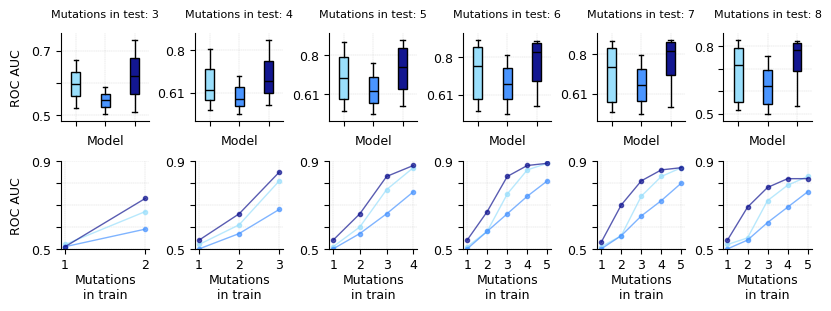

[0.05031727 0.03711069 0.06774285 0.02769926 0.03022819]
#########################
[0 1]
21    0.69
68    0.73
Name: precision, dtype: float64
#########################
#########################
[0 1]
6     0.69
29    0.73
Name: precision, dtype: float64
#########################
#########################
[0 1]
89    0.69
97    0.73
Name: precision, dtype: float64
#########################
[0.05031727 0.03711069 0.06774285 0.02769926 0.03022819]
#########################
[0 1 2]
22    0.45
69    0.49
44    0.59
Name: precision, dtype: float64
#########################
#########################
[0 1 2]
7     0.45
30    0.49
81    0.57
Name: precision, dtype: float64
#########################
#########################
[0 1 2]
90    0.45
98    0.48
37    0.56
Name: precision, dtype: float64
#########################
[0.05031727 0.03711069 0.06774285 0.02769926 0.03022819]
#########################
[0 1 2 3]
23    0.27
70    0.31
45    0.39
51    0.51
Name: precision, dtype: float64
######

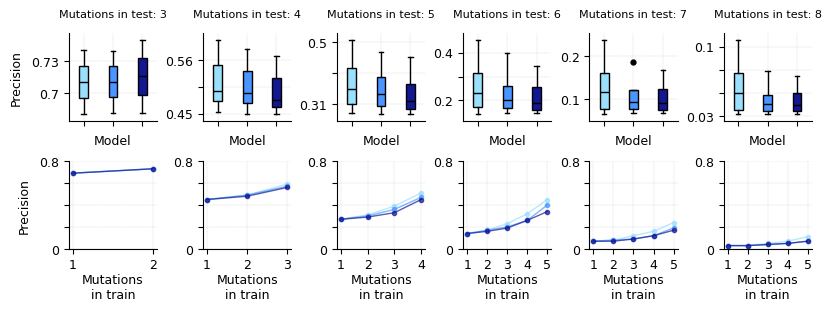

[0.09503726 0.07136072 0.12434048 0.05390537 0.05859459]
#########################
[0 1]
21    0.80
68    0.82
Name: f1, dtype: float64
#########################
#########################
[0 1]
6     0.81
29    0.83
Name: f1, dtype: float64
#########################
#########################
[0 1]
89    0.81
97    0.84
Name: f1, dtype: float64
#########################
[0.09503726 0.07136072 0.12434048 0.05390537 0.05859459]
#########################
[0 1 2]
22    0.61
69    0.63
44    0.71
Name: f1, dtype: float64
#########################
#########################
[0 1 2]
7     0.62
30    0.65
81    0.71
Name: f1, dtype: float64
#########################
#########################
[0 1 2]
90    0.62
98    0.64
37    0.70
Name: f1, dtype: float64
#########################
[0.09503726 0.07136072 0.12434048 0.05390537 0.05859459]
#########################
[0 1 2 3]
23    0.42
70    0.44
45    0.54
51    0.64
Name: f1, dtype: float64
#########################
#########################
[0 

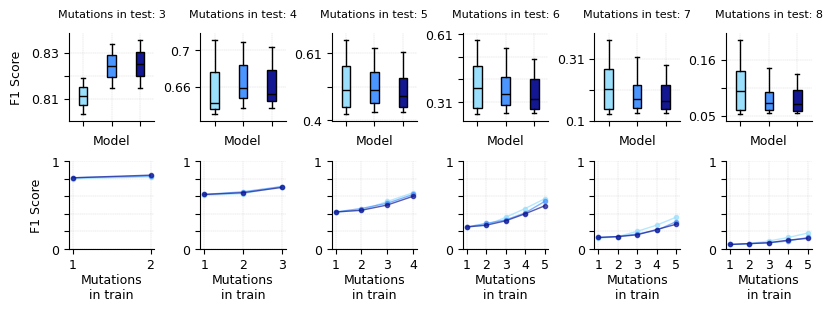

[0.54932437 0.3326157  0.70514773 0.02770776 0.15325912]
#########################
[0 1]
21    0.68
68    0.72
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
6     0.69
29    0.73
Name: accuracy, dtype: float64
#########################
#########################
[0 1]
89    0.69
97    0.74
Name: accuracy, dtype: float64
#########################
[0.54932437 0.3326157  0.70514773 0.02770776 0.15325912]
#########################
[0 1 2]
22    0.46
69    0.54
44    0.67
Name: accuracy, dtype: float64
#########################
#########################
[0 1 2]
7     0.45
30    0.53
81    0.65
Name: accuracy, dtype: float64
#########################
#########################
[0 1 2]
90    0.45
98    0.51
37    0.64
Name: accuracy, dtype: float64
#########################
[0.54932437 0.3326157  0.70514773 0.02770776 0.15325912]
#########################
[0 1 2 3]
23    0.31
70    0.47
45    0.59
51    0.74
Name: accuracy, dtype: float64
#############

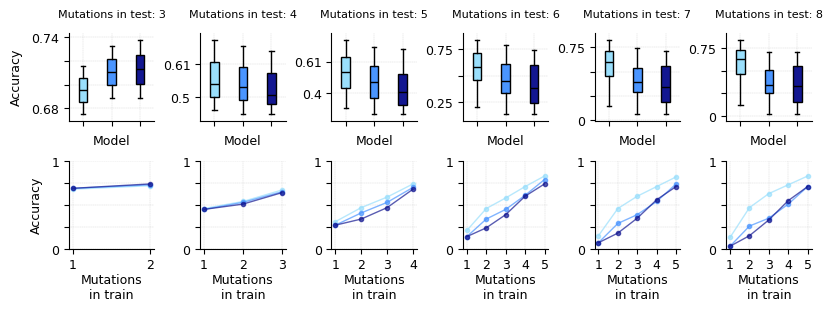

[0.85434439 0.92575039 0.75576619 1.         0.95134281]
#########################
[0 1]
21    0.97
68    0.94
Name: recall, dtype: float64
#########################
#########################
[0 1]
6     1.00
29    0.98
Name: recall, dtype: float64
#########################
#########################
[0 1]
89    1.00
97    0.97
Name: recall, dtype: float64
#########################
[0.85434439 0.92575039 0.75576619 1.         0.95134281]
#########################
[0 1 2]
22    0.95
69    0.86
44    0.91
Name: recall, dtype: float64
#########################
#########################
[0 1 2]
7     1.00
30    0.96
81    0.95
Name: recall, dtype: float64
#########################
#########################
[0 1 2]
90    1.00
98    0.98
37    0.96
Name: recall, dtype: float64
#########################
[0.85434439 0.92575039 0.75576619 1.         0.95134281]
#########################
[0 1 2 3]
23    0.93
70    0.78
45    0.87
51    0.86
Name: recall, dtype: float64
#########################
#

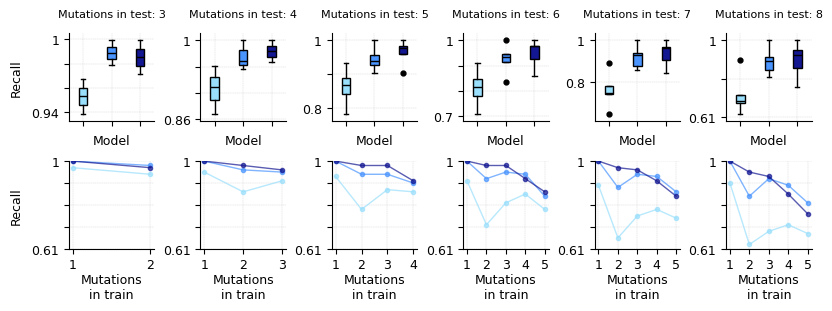

#########################
[0 1]
21    0.64
68    0.81
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
6     0.62
29    0.64
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1]
89    0.35
97    0.89
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2]
22    0.61
69    0.60
44    0.95
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2]
7     0.41
30    0.53
81    0.79
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2]
90    0.36
98    0.61
37    1.00
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2 3]
23    0.28
70    0.40
45    0.67
51    0.97
Name: top_100_pct, dtype: float64
#########################
#########################
[0 1 2 3]
8     0.51
31    0.50
82    0.22
57    0.39
Name: top_100_pct, dtype: float64
#######################

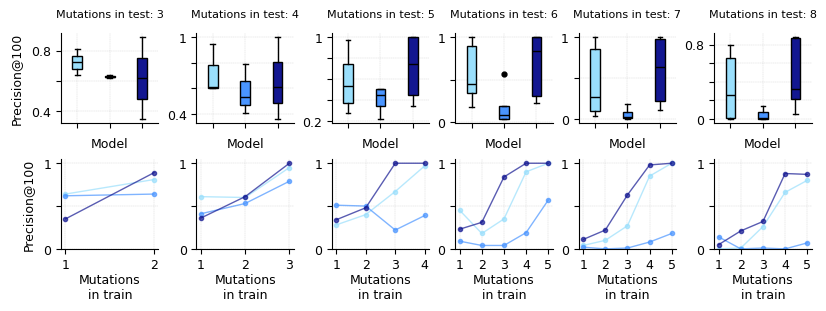


Processing model directory: esm_8m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_model_comp/esm_8m
Found 15 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_model_comp/esm_8m
Reading CSV file: esm_8m_evaluation_train_on_5_xgboost.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_1_ridgeregression.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_4_mlp.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_1_xgboost.csv
Index(['correlat

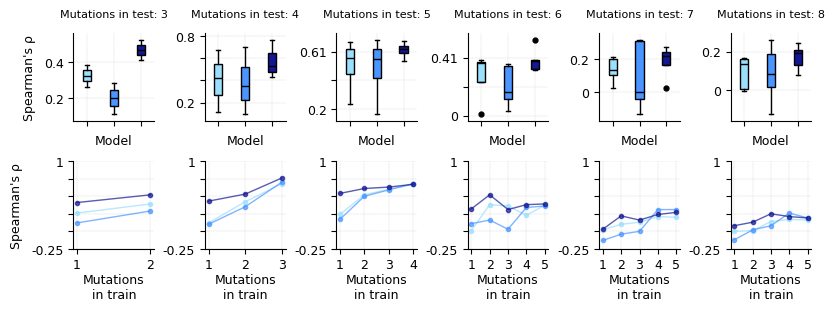


Processing model directory: esm_8m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_model_comp/esm_8m
Found 15 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_model_comp/esm_8m
Reading CSV file: esm_8m_evaluation_train_on_5_xgboost.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_1_ridgeregression.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_4_mlp.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_1_xgboost.csv
Index(['correlation', 'p

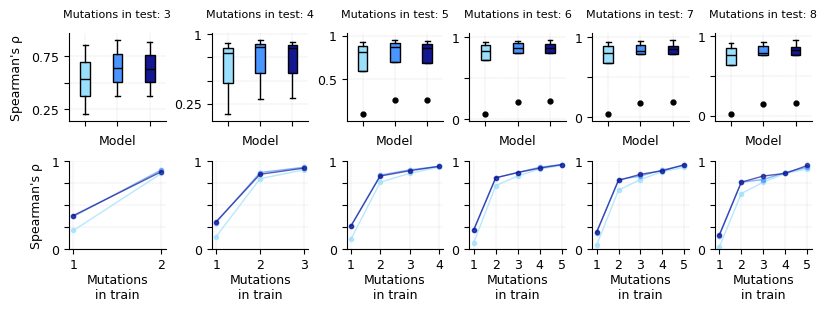

In [29]:
def load_df_all_new(embedding_base_dir, one_hot=False):

    df_all_list = []

    experiment_dirs = [d for d in os.listdir(embedding_base_dir) if os.path.isdir(os.path.join(embedding_base_dir, d))]
    llms_experiment_dirs = [e for e in experiment_dirs if e != "one_hot"]

    for exp_subdir in llms_experiment_dirs:
        exp_path = os.path.join(embedding_base_dir, exp_subdir)
        csv_files = [f for f in os.listdir(exp_path) if f.endswith('.csv')]
        print(f"\nProcessing model directory: {exp_subdir} at {exp_path}")
        print(f"Found {len(csv_files)} csv files in {exp_path}")

        for csv_file in csv_files:
            csv_path = os.path.join(exp_path, csv_file)
            print(f"Reading CSV file: {csv_file}")
            df = pd.read_csv(csv_path)
            df["model"] = exp_subdir
            df_all_list.append(df)
            print(df.columns)

    if len(df_all_list) > 0:
        df_all = pd.concat(df_all_list, ignore_index=True)
        print(f"\nConcatenating {len(df_all_list)} dataframes into df_all...")
        print(f"df_all shape: {df_all.shape}")
    else:
        df_all = pd.DataFrame()


    if one_hot:
        ohe_experiment_dirs = [e for e in experiment_dirs if e == "one_hot"][0]
        ohe_df_all_list = []
        ohe_dir = os.path.join(embedding_base_dir, ohe_experiment_dirs)
        csv_files = [f for f in os.listdir(ohe_dir) if f.endswith('.csv')]
        for csv_file in csv_files:
            df = pd.read_csv(os.path.join(ohe_dir, csv_file))
            ohe_df_all_list.append(df)
        if len(ohe_df_all_list) > 0:
            ohe_df_all = pd.concat(ohe_df_all_list, ignore_index=True)
        else:
            ohe_df_all = pd.DataFrame()

        ohe_df_all["model_name"] = "ohe"

        return (df_all, ohe_df_all)

    return df_all



new_color_map = {
    "xgboost": "#9adffc",
    "ridgeregression": "#4a95ff",
    "mlp": "#131791",
}

for dataset_name in ["gfp", "pard3", "lov"]:

    a = load_df_all_new("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/%s/%s_regression_model_comp/" % (dataset_name, dataset_name), one_hot=False)
    a["model_name"] = a["clf_type"]

    for feature in var_to_use_dict[dataset_name]:
        plot_mutation_model_performance(
                    new_color_map,
                    a,
                    pred_begin,
                    min_muts,
                    n_muts_to_check,
                    feature,
                    min_max_y=True,
                    output_dir="./refined_figures/supp_figure_model_selection/%s/" % dataset_name,
                    #probabilities_by_mutations,
                    #output_dir="./figures/figure_3_regular/"
                )